# Phase 5 — Live 72-Hour PM2.5 Inference Pipeline

- **5A.** Inspect and lock the inference contract
- **5B.** Configuration and model loading
- **5C.** Extract and verify reusable feature logic
- **5D.** Implement OpenAQ and Open-Meteo clients
- **5E.** Select a safe reference timestamp
- **5F.** Build and validate 72 feature rows
- **5G.** Generate hybrid predictions
- **5H.** Save and validate the complete run

## **5A.** Inspect and lock the inference contract

The objective of Phase 5 is to generate 72 hourly PM2.5 predictions using:

- recent OpenAQ PM2.5 observations
- Open-Meteo current and forecast weather
- the saved hybrid forecasting strategy
- the exact feature definitions used during training

Before implementing API clients or live prediction code, the training-serving
contract must be inspected and documented.

This subphase confirms:

- the saved model and contracts are available
- the selected hybrid routing rule is preserved
- the exact ordered model features are known
- target and identifier columns are excluded from model inputs
- required PM2.5 lag, rolling, and change windows are identified
- current-weather and target-weather inputs are identified
- Phase 2 feature-generation code is available for extraction
- the minimum live PM2.5 history requirement can be determined

No API requests, feature generation, or predictions are performed yet.

In [2]:
from pathlib import Path
import json
import re

import joblib
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / "models"
TRAINING_DATA_DIR = PROJECT_ROOT / "data" / "training"
EXPLAINABILITY_DIR = PROJECT_ROOT / "explainability"
ERROR_ANALYSIS_DIR = PROJECT_ROOT / "error_analysis"
REPORTS_DIR = PROJECT_ROOT / "reports"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"


BEST_MODEL_PATH = MODELS_DIR / "best_model.joblib"
MODEL_FEATURE_CONTRACT_PATH = (
    MODELS_DIR / "model_feature_columns.json"
)
MODEL_METADATA_PATH = MODELS_DIR / "model_metadata.json"
MODEL_SELECTION_REPORT_PATH = (
    MODELS_DIR / "model_selection_report.json"
)

PHASE_2_FEATURE_CONTRACT_PATH = (
    TRAINING_DATA_DIR / "feature_columns.json"
)
PHASE_2_VALIDATION_REPORT_PATH = (
    TRAINING_DATA_DIR / "phase_2_validation_report.json"
)

PHASE_2_NOTEBOOK_PATH = (
    NOTEBOOKS_DIR / "03_build_training_dataset.ipynb"
)

PHASE_4_EXPLAINABILITY_REPORT_PATH = (
    EXPLAINABILITY_DIR
    / "phase_4_explainability_report.json"
)

PHASE_4_ERROR_REPORT_PATH = (
    ERROR_ANALYSIS_DIR
    / "phase_4_error_analysis_report.json"
)


print("Project root:", PROJECT_ROOT)
print("Phase 2 notebook:", PHASE_2_NOTEBOOK_PATH)

Project root: /home/riyan/Riyan/projects/pearls-aqi-predictor
Phase 2 notebook: /home/riyan/Riyan/projects/pearls-aqi-predictor/notebooks/03_build_training_dataset.ipynb


### Verify saved Phase 2, Phase 3, and Phase 4 artifacts

Live inference must use the exact model and feature definitions already
validated during earlier phases.

This check prevents the pipeline from silently using:

- an incorrect model
- a reordered feature list
- incomplete metadata
- unvalidated feature formulas

In [3]:
required_phase_5a_artifacts = {
    "saved model": BEST_MODEL_PATH,
    "model feature contract": MODEL_FEATURE_CONTRACT_PATH,
    "model metadata": MODEL_METADATA_PATH,
    "model selection report": MODEL_SELECTION_REPORT_PATH,
    "Phase 2 feature contract": PHASE_2_FEATURE_CONTRACT_PATH,
    "Phase 2 validation report": PHASE_2_VALIDATION_REPORT_PATH,
    "Phase 2 feature notebook": PHASE_2_NOTEBOOK_PATH,
    "Phase 4 explainability report": (
        PHASE_4_EXPLAINABILITY_REPORT_PATH
    ),
    "Phase 4 error-analysis report": (
        PHASE_4_ERROR_REPORT_PATH
    ),
}

phase_5a_artifact_status_df = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else None
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in required_phase_5a_artifacts.items()
    ]
)

display(phase_5a_artifact_status_df)

missing_artifacts = phase_5a_artifact_status_df.loc[
    ~phase_5a_artifact_status_df["exists"],
    "artifact",
].tolist()

assert not missing_artifacts, (
    "Missing required Phase 5A artifacts: "
    f"{missing_artifacts}"
)

print("All required Phase 5A artifacts exist.")

,artifact,exists,size_bytes,path
0,saved model,True,677236,/home/riyan/Riyan/projects/pearls-aqi-predicto...
1,model feature contract,True,1653,/home/riyan/Riyan/projects/pearls-aqi-predicto...
2,model metadata,True,5609,/home/riyan/Riyan/projects/pearls-aqi-predicto...
3,model selection report,True,4088,/home/riyan/Riyan/projects/pearls-aqi-predicto...
4,Phase 2 feature contract,True,1624,/home/riyan/Riyan/projects/pearls-aqi-predicto...
5,Phase 2 validation report,True,2179,/home/riyan/Riyan/projects/pearls-aqi-predicto...
6,Phase 2 feature notebook,True,319422,/home/riyan/Riyan/projects/pearls-aqi-predicto...
7,Phase 4 explainability report,True,3351,/home/riyan/Riyan/projects/pearls-aqi-predicto...
8,Phase 4 error-analysis report,True,2838,/home/riyan/Riyan/projects/pearls-aqi-predicto...


All required Phase 5A artifacts exist.


### Load the saved model and feature contracts

The model feature contract is the source of truth for the final model input
schema.

The Phase 2 feature contract is also loaded so both contracts can be compared.

The saved metadata provides the selected hybrid routing rule:

- persistence for horizons 1–12
- XGBoost for horizons 13–72

In [4]:
def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


model_feature_contract = load_json(
    MODEL_FEATURE_CONTRACT_PATH
)

model_metadata = load_json(
    MODEL_METADATA_PATH
)

model_selection_report = load_json(
    MODEL_SELECTION_REPORT_PATH
)

phase_2_feature_contract = load_json(
    PHASE_2_FEATURE_CONTRACT_PATH
)

phase_2_validation_report = load_json(
    PHASE_2_VALIDATION_REPORT_PATH
)

phase_4_explainability_report = load_json(
    PHASE_4_EXPLAINABILITY_REPORT_PATH
)

phase_4_error_report = load_json(
    PHASE_4_ERROR_REPORT_PATH
)

In [5]:
MODEL_FEATURE_COLUMNS = model_feature_contract[
    "feature_columns"
]

TARGET_COLUMN = model_feature_contract[
    "target_column"
]

IDENTIFIER_COLUMNS = model_feature_contract[
    "identifier_columns"
]

SELECTED_STRATEGY_NAME = model_metadata[
    "selected_strategy"
]

PERSISTENCE_MAX_HORIZON = int(
    model_metadata["routing"][
        "persistence_max_horizon"
    ]
)

XGBOOST_MODEL_NAME = model_metadata[
    "model_name"
]


print("Model feature count:", len(MODEL_FEATURE_COLUMNS))
print("Target column:", TARGET_COLUMN)
print("Identifier columns:", IDENTIFIER_COLUMNS)
print("Selected strategy:", SELECTED_STRATEGY_NAME)
print("Saved XGBoost model:", XGBOOST_MODEL_NAME)
print(
    "Persistence maximum horizon:",
    PERSISTENCE_MAX_HORIZON,
)

Model feature count: 56
Target column: target_pm25_ug_m3
Identifier columns: ['reference_time', 'target_time']
Selected strategy: hybrid_persistence_1_12_xgboost_shallower_13_72
Saved XGBoost model: xgboost_shallower
Persistence maximum horizon: 12


### Validate the saved estimator

The fitted model is loaded only to confirm its type and expected feature count.

It is not trained or used for prediction in Phase 5A.

In [6]:
saved_model = joblib.load(
    BEST_MODEL_PATH
)

print("Loaded model type:", type(saved_model).__name__)
print(
    "Model feature count:",
    getattr(saved_model, "n_features_in_", None),
)

assert type(saved_model).__name__ == "XGBRegressor"

assert saved_model.n_features_in_ == len(
    MODEL_FEATURE_COLUMNS
)

print("Saved model contract validated.")

Loaded model type: XGBRegressor
Model feature count: 56
Saved model contract validated.


### Compare the Phase 2 and final model feature lists

The final model feature list must remain consistent with the feature order
produced by Phase 2.

Any difference in names or order must be investigated before implementing live
inference.

In [7]:
phase_2_feature_columns = phase_2_feature_contract[
    "feature_columns"
]

feature_contract_comparison = {
    "phase_2_feature_count": len(
        phase_2_feature_columns
    ),
    "model_feature_count": len(
        MODEL_FEATURE_COLUMNS
    ),
    "same_feature_names": (
        set(phase_2_feature_columns)
        == set(MODEL_FEATURE_COLUMNS)
    ),
    "same_feature_order": (
        phase_2_feature_columns
        == MODEL_FEATURE_COLUMNS
    ),
}

display(
    pd.Series(
        feature_contract_comparison,
        name="value",
    ).to_frame()
)

assert feature_contract_comparison[
    "same_feature_names"
]

assert feature_contract_comparison[
    "same_feature_order"
]

print(
    "Phase 2 and model feature contracts match exactly."
)

,value
phase_2_feature_count,56
model_feature_count,56
same_feature_names,True
same_feature_order,True


Phase 2 and model feature contracts match exactly.


### Confirm that metadata and target columns are excluded

The model input must not include:

- `target_pm25_ug_m3`
- `reference_time`
- `target_time`

These columns are retained only for training labels, row identification, and
output metadata.

In [8]:
forbidden_model_columns = [
    TARGET_COLUMN,
    *IDENTIFIER_COLUMNS,
]

forbidden_columns_present = [
    column
    for column in forbidden_model_columns
    if column in MODEL_FEATURE_COLUMNS
]

print(
    "Forbidden columns present in model input:",
    forbidden_columns_present,
)

assert not forbidden_columns_present

assert (
    "forecast_horizon_hours"
    in MODEL_FEATURE_COLUMNS
)

print(
    "Target and identifier exclusion validated."
)

Forbidden columns present in model input: []
Target and identifier exclusion validated.


### Identify live feature groups

The ordered model feature list is grouped into:

- PM2.5 history features
- current-weather features
- target-hour weather features
- reference-time features
- target-time features
- forecast-horizon feature

This identifies which live data must be collected before inference.

In [9]:
PM25_FEATURE_PREFIXES = (
    "pm25_",
)

TARGET_WEATHER_PREFIX = "target_"

TIME_FEATURE_KEYWORDS = (
    "hour",
    "day_of_week",
    "month",
)

pm25_feature_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column.startswith(PM25_FEATURE_PREFIXES)
]

target_weather_feature_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column.startswith(TARGET_WEATHER_PREFIX)
    and not any(
        keyword in column
        for keyword in TIME_FEATURE_KEYWORDS
    )
]

forecast_horizon_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column == "forecast_horizon_hours"
]

reference_time_feature_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column.startswith("reference_")
]

target_time_feature_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if column.startswith("target_")
    and any(
        keyword in column
        for keyword in TIME_FEATURE_KEYWORDS
    )
]

In [10]:
CANONICAL_WEATHER_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "surface_pressure",
    "precipitation",
    "rain",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
]

current_weather_feature_columns = [
    column
    for column in MODEL_FEATURE_COLUMNS
    if (
        column in CANONICAL_WEATHER_COLUMNS
        or column
        in {
            "wind_direction_10m_sin",
            "wind_direction_10m_cos",
        }
    )
]

In [11]:
feature_group_summary_df = pd.DataFrame(
    [
        {
            "feature_group": "PM2.5 history",
            "feature_count": len(
                pm25_feature_columns
            ),
            "features": pm25_feature_columns,
        },
        {
            "feature_group": "Current weather",
            "feature_count": len(
                current_weather_feature_columns
            ),
            "features": (
                current_weather_feature_columns
            ),
        },
        {
            "feature_group": "Target weather",
            "feature_count": len(
                target_weather_feature_columns
            ),
            "features": (
                target_weather_feature_columns
            ),
        },
        {
            "feature_group": "Reference time",
            "feature_count": len(
                reference_time_feature_columns
            ),
            "features": (
                reference_time_feature_columns
            ),
        },
        {
            "feature_group": "Target time",
            "feature_count": len(
                target_time_feature_columns
            ),
            "features": (
                target_time_feature_columns
            ),
        },
        {
            "feature_group": "Forecast horizon",
            "feature_count": len(
                forecast_horizon_columns
            ),
            "features": forecast_horizon_columns,
        },
    ]
)

display(feature_group_summary_df)

,feature_group,feature_count,features
0,PM2.5 history,13,"[pm25_current, pm25_lag_1h, pm25_lag_3h, pm25_..."
1,Current weather,12,"[temperature_2m, relative_humidity_2m, dew_poi..."
2,Target weather,12,"[target_temperature_2m, target_relative_humidi..."
3,Reference time,9,"[reference_hour, reference_day_of_week, refere..."
4,Target time,9,"[target_hour, target_day_of_week, target_month..."
5,Forecast horizon,1,[forecast_horizon_hours]


### Infer PM2.5 history requirements from feature names

The feature names reveal the lag offsets, rolling windows, and change periods
required by the model.

This gives an initial estimate of the live PM2.5 lookback requirement.

The final formulas must still be confirmed against the actual Phase 2 notebook
code before implementation.

In [12]:
def extract_hours(
    feature_names: list[str],
    pattern: str,
) -> list[int]:
    extracted_values = []

    for feature_name in feature_names:
        match = re.fullmatch(
            pattern,
            feature_name,
        )

        if match:
            extracted_values.append(
                int(match.group(1))
            )

    return sorted(set(extracted_values))


required_lag_hours = extract_hours(
    pm25_feature_columns,
    r"pm25_lag_(\d+)h",
)

required_rolling_windows = extract_hours(
    pm25_feature_columns,
    r"pm25_mean_(\d+)h",
)

required_change_hours = extract_hours(
    pm25_feature_columns,
    r"pm25_change_(\d+)h",
)


print("Required PM2.5 lags:", required_lag_hours)
print(
    "Required rolling windows:",
    required_rolling_windows,
)
print(
    "Required change periods:",
    required_change_hours,
)

Required PM2.5 lags: [1, 3, 6, 12, 24]
Required rolling windows: [3, 6, 12, 24]
Required change periods: [1, 6, 24]


In [13]:
largest_required_lag = max(
    required_lag_hours,
    default=0,
)

largest_rolling_window = max(
    required_rolling_windows,
    default=0,
)

largest_change_period = max(
    required_change_hours,
    default=0,
)

minimum_history_hours_from_names = max(
    largest_required_lag,
    largest_rolling_window,
    largest_change_period,
)


history_requirement_summary = {
    "largest_required_lag_hours": (
        largest_required_lag
    ),
    "largest_rolling_window_hours": (
        largest_rolling_window
    ),
    "largest_change_period_hours": (
        largest_change_period
    ),
    "minimum_history_hours_from_feature_names": (
        minimum_history_hours_from_names
    ),
}

display(
    pd.Series(
        history_requirement_summary,
        name="value",
    ).to_frame()
)

,value
largest_required_lag_hours,24
largest_rolling_window_hours,24
largest_change_period_hours,24
minimum_history_hours_from_feature_names,24


### Inspect the actual Phase 2 feature-generation code

Feature names alone are not enough to guarantee training-serving consistency.

The Phase 2 notebook is inspected for code related to:

- PM2.5 lags
- rolling means
- PM2.5 changes
- cyclical time encodings
- wind-direction encodings
- target-weather column mapping

The displayed code snippets will be used as the source for the reusable feature
module in Phase 5C.

In [14]:
phase_2_notebook = load_json(
    PHASE_2_NOTEBOOK_PATH
)

phase_2_code_cells = [
    "".join(cell.get("source", []))
    for cell in phase_2_notebook.get(
        "cells",
        [],
    )
    if cell.get("cell_type") == "code"
]

print(
    "Phase 2 code cells:",
    len(phase_2_code_cells),
)

Phase 2 code cells: 96


In [15]:
FEATURE_LOGIC_KEYWORDS = [
    "PM25_LAG",
    "PM25_ROLLING",
    "PM25_CHANGE",
    "shift(",
    "rolling(",
    "min_periods",
    "np.sin",
    "np.cos",
    "wind_direction",
    "target_",
    "forecast_horizon_hours",
]

relevant_phase_2_cells = []

for cell_index, cell_source in enumerate(
    phase_2_code_cells
):
    matching_keywords = [
        keyword
        for keyword in FEATURE_LOGIC_KEYWORDS
        if keyword in cell_source
    ]

    if matching_keywords:
        relevant_phase_2_cells.append(
            {
                "code_cell_index": cell_index,
                "matching_keywords": (
                    matching_keywords
                ),
                "source": cell_source,
            }
        )

print(
    "Relevant Phase 2 code cells found:",
    len(relevant_phase_2_cells),
)

Relevant Phase 2 code cells found: 56


In [16]:
for record in relevant_phase_2_cells:
    print("=" * 90)
    print(
        "Code cell index:",
        record["code_cell_index"],
    )
    print(
        "Matching keywords:",
        record["matching_keywords"],
    )
    print("-" * 90)
    print(record["source"])
    print()

Code cell index: 4
Matching keywords: ['wind_direction']
------------------------------------------------------------------------------------------
WEATHER_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "surface_pressure",
    "precipitation",
    "rain",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
]


REQUIRED_CANONICAL_COLUMNS = [
    "datetime_utc",
    "sensor_id",
    "location_id",
    "location_name",
    "provider",
    "pm25_ug_m3",
    "pm25_missing",
    "pm25_zero_flag",
    "pm25_negative_flag",
    *WEATHER_COLUMNS,
]


missing_required_columns = [
    column
    for column in REQUIRED_CANONICAL_COLUMNS
    if column not in canonical_df.columns
]

unexpected_columns = [
    column
    for column in canonical_df.columns
    if column not in REQUIRED_CANONICAL_COLUMNS
]


print("Missing required columns:", missing_required_columns)
print("Unexpected columns:", unexpected_columns)

Code cell 

### Confirm readiness for live inference

Phase 4 must have approved the saved model for live inference, with any
limitations preserved.

The expected status is:

`APPROVED_WITH_LIMITATIONS`

In [17]:
phase_4_explainability_status = (
    phase_4_explainability_report.get(
        "approval_status"
    )
)

phase_4_error_status = (
    phase_4_error_report.get(
        "approval_status"
    )
)

readiness_summary_df = pd.DataFrame(
    [
        {
            "report": "explainability",
            "approval_status": (
                phase_4_explainability_status
            ),
        },
        {
            "report": "error_analysis",
            "approval_status": (
                phase_4_error_status
            ),
        },
    ]
)

display(readiness_summary_df)

allowed_readiness_statuses = {
    "APPROVED_FOR_LIVE_INFERENCE",
    "APPROVED_WITH_LIMITATIONS",
}

assert (
    phase_4_explainability_status
    in allowed_readiness_statuses
)

assert (
    phase_4_error_status
    in allowed_readiness_statuses
)

print(
    "Phase 4 readiness permits live-inference development."
)

,report,approval_status
0,explainability,APPROVED_WITH_LIMITATIONS
1,error_analysis,APPROVED_WITH_LIMITATIONS


Phase 4 readiness permits live-inference development.


### Preliminary live-input contract

Based on the saved model feature list, the live pipeline will require:

### Pollution input

A recent hourly PM2.5 timeline ending at the selected reference timestamp.

Every required lag must exist at its exact UTC timestamp. Missing timestamps
will not be replaced with the previous available observation.

### Current weather input

Weather values aligned with the selected reference timestamp.

### Forecast weather input

Weather values for every target timestamp from:

`reference_time + 1 hour`

through:

`reference_time + 72 hours`

### Inference output

Exactly 72 model-input rows sharing one reference timestamp and containing
forecast horizons 1 through 72.

In [18]:
preliminary_live_input_contract = {
    "location": {
        "name": "Zafar Memon DHA",
        "latitude": 24.814741,
        "longitude": 67.067062,
        "openaq_location_id": 4814327,
        "openaq_sensor_id": 13387396,
    },
    "timezone": "UTC",
    "forecast_horizons": {
        "minimum": 1,
        "maximum": 72,
        "count": 72,
    },
    "model": {
        "type": type(saved_model).__name__,
        "name": XGBOOST_MODEL_NAME,
        "feature_count": len(
            MODEL_FEATURE_COLUMNS
        ),
        "selected_strategy": (
            SELECTED_STRATEGY_NAME
        ),
        "persistence_max_horizon": (
            PERSISTENCE_MAX_HORIZON
        ),
    },
    "pm25_history": {
        "required_lag_hours": (
            required_lag_hours
        ),
        "required_rolling_windows": (
            required_rolling_windows
        ),
        "required_change_hours": (
            required_change_hours
        ),
        "largest_required_history_hours": (
            minimum_history_hours_from_names
        ),
        "interpolation_allowed": False,
        "exact_hour_alignment_required": True,
    },
    "weather": {
        "canonical_variables": (
            CANONICAL_WEATHER_COLUMNS
        ),
        "current_weather_features": (
            current_weather_feature_columns
        ),
        "target_weather_features": (
            target_weather_feature_columns
        ),
        "visibility_used": False,
    },
    "time_features": {
        "reference_features": (
            reference_time_feature_columns
        ),
        "target_features": (
            target_time_feature_columns
        ),
    },
    "feature_order": MODEL_FEATURE_COLUMNS,
    "target_column_is_model_input": (
        TARGET_COLUMN
        in MODEL_FEATURE_COLUMNS
    ),
}

display(
    pd.Series(
        {
            "model_features": len(
                MODEL_FEATURE_COLUMNS
            ),
            "largest_required_history_hours": (
                minimum_history_hours_from_names
            ),
            "current_weather_features": len(
                current_weather_feature_columns
            ),
            "target_weather_features": len(
                target_weather_feature_columns
            ),
            "reference_time_features": len(
                reference_time_feature_columns
            ),
            "target_time_features": len(
                target_time_feature_columns
            ),
        },
        name="value",
    ).to_frame()
)

,value
model_features,56
largest_required_history_hours,24
current_weather_features,12
target_weather_features,12
reference_time_features,9
target_time_features,9


In [19]:
assert len(MODEL_FEATURE_COLUMNS) == 56

assert TARGET_COLUMN not in MODEL_FEATURE_COLUMNS

assert not any(
    identifier_column
    in MODEL_FEATURE_COLUMNS
    for identifier_column
    in IDENTIFIER_COLUMNS
)

assert required_lag_hours
assert required_rolling_windows
assert required_change_hours

assert largest_required_lag == 24
assert largest_rolling_window == 24
assert largest_change_period == 24

assert PERSISTENCE_MAX_HORIZON == 12

assert preliminary_live_input_contract[
    "target_column_is_model_input"
] is False

print("Phase 5A inference-contract inspection passed.")

Phase 5A inference-contract inspection passed.


## **5B.** Central configuration and model loading

Live inference requires a single source of truth for project settings and saved
model artifacts.

This subphase moves configuration and artifact loading into reusable Python
modules.

The configuration module defines:

- location and sensor identifiers
- forecast horizon
- hybrid routing threshold
- PM2.5 history requirements
- request behavior
- project artifact paths
- secure OpenAQ credential access

The predictor module loads and validates:

- the fitted XGBoost model
- the exact ordered feature contract
- Phase 2 feature parity
- model metadata
- Phase 4 readiness status

No API requests or predictions are performed.

In [20]:
import importlib

import app.core.config
import app.inference.predictor

importlib.reload(app.core.config)
importlib.reload(app.inference.predictor)

from app.core.config import settings
from app.inference.predictor import (
    ArtifactContractError,
    load_model_artifacts,
    validate_feature_matrix,
)

### Inspect centralized configuration

The live inference configuration is loaded directly from the project source
code rather than being duplicated inside the notebook.

In [21]:
configuration_summary = {
    "project_name": settings.project_name,
    "location_name": settings.location_name,
    "latitude": settings.latitude,
    "longitude": settings.longitude,
    "openaq_location_id": settings.openaq_location_id,
    "openaq_sensor_id": settings.openaq_sensor_id,
    "forecast_horizon_hours": (
        settings.forecast_horizon_hours
    ),
    "persistence_max_horizon": (
        settings.persistence_max_horizon
    ),
    "minimum_pm25_history_hours": (
        settings.minimum_pm25_history_hours
    ),
    "history_safety_buffer_hours": (
        settings.pm25_history_safety_buffer_hours
    ),
    "requested_pm25_lookback_hours": (
        settings.requested_pm25_lookback_hours
    ),
    "pm25_freshness_threshold_hours": (
        settings.pm25_freshness_threshold_hours
    ),
    "request_timeout_seconds": (
        settings.request_timeout_seconds
    ),
    "request_retry_count": (
        settings.request_retry_count
    ),
}

display(
    pd.Series(
        configuration_summary,
        name="value",
    ).to_frame()
)

,value
project_name,Pearls AQI Predictor
location_name,Zafar Memon DHA
latitude,24.814741
longitude,67.067062
openaq_location_id,4814327
openaq_sensor_id,13387396
forecast_horizon_hours,72
persistence_max_horizon,12
minimum_pm25_history_hours,24
history_safety_buffer_hours,48


### Validate secure credential handling

Phase 5B checks only whether an OpenAQ key is configured.

The key itself is never printed.

In [22]:
openaq_key_is_configured = (
    settings.openaq_api_key is not None
)

print(
    "OpenAQ API key configured:",
    openaq_key_is_configured,
)

OpenAQ API key configured: True


### Load the validated model package

The artifact loader verifies all contracts before returning the saved model.

A failure at this stage prevents the live pipeline from continuing with an
incomplete or inconsistent model package.

In [23]:
model_artifacts = load_model_artifacts(
    settings
)

artifact_contract_summary = {
    "model_type": model_artifacts.model_type,
    "model_name": model_artifacts.model_name,
    "selected_strategy": (
        model_artifacts.selected_strategy
    ),
    "feature_count": len(
        model_artifacts.feature_columns
    ),
    "target_column": (
        model_artifacts.target_column
    ),
    "identifier_columns": (
        model_artifacts.identifier_columns
    ),
    "persistence_max_horizon": (
        model_artifacts.persistence_max_horizon
    ),
}

display(
    pd.Series(
        artifact_contract_summary,
        name="value",
    ).to_frame()
)

,value
model_type,XGBRegressor
model_name,xgboost_shallower
selected_strategy,hybrid_persistence_1_12_xgboost_shallower_13_72
feature_count,56
target_column,target_pm25_ug_m3
identifier_columns,"[reference_time, target_time]"
persistence_max_horizon,12


In [24]:
ordered_feature_preview_df = pd.DataFrame(
    {
        "position": range(
            1,
            len(model_artifacts.feature_columns) + 1,
        ),
        "feature": model_artifacts.feature_columns,
    }
)

display(
    ordered_feature_preview_df.head(15)
)

display(
    ordered_feature_preview_df.tail(10)
)

,position,feature
0,1,pm25_current
1,2,pm25_lag_1h
2,3,pm25_lag_3h
3,4,pm25_lag_6h
4,5,pm25_lag_12h
5,6,pm25_lag_24h
6,7,pm25_mean_3h
7,8,pm25_mean_6h
8,9,pm25_mean_12h
9,10,pm25_mean_24h


,position,feature
46,47,target_wind_direction_10m_cos
47,48,target_hour
48,49,target_day_of_week
49,50,target_month
50,51,target_hour_sin
51,52,target_hour_cos
52,53,target_day_of_week_sin
53,54,target_day_of_week_cos
54,55,target_month_sin
55,56,target_month_cos


### Confirm API-key failure behavior

Live requests must fail clearly when the OpenAQ API key is missing.

The following check verifies that credential validation works without exposing
the secret.

In [25]:
if settings.openaq_api_key is None:
    try:
        settings.require_openaq_api_key()
    except RuntimeError as exc:
        print("Expected configuration error:")
        print(exc)
else:
    validated_key = settings.require_openaq_api_key()

    assert validated_key
    print(
        "OpenAQ credential validation passed. "
        "The key was not displayed."
    )

OpenAQ credential validation passed. The key was not displayed.


## **5C.** Reusable feature builder and training-serving parity

The feature calculations created during Phase 2 are now moved into reusable
Python functions.

The feature builder handles:

- exact PM2.5 lags
- complete rolling PM2.5 means
- PM2.5 changes
- current-weather features
- target-hour weather features
- wind-direction sine and cosine encodings
- reference-time encodings
- target-time encodings
- forecast-horizon expansion
- final model feature ordering

Before using live API data, the reusable implementation is compared against
the saved Phase 2 model-ready dataset.

This comparison verifies training-serving parity without retraining the model.

In [26]:
import importlib

import app.features.live_feature_builder

importlib.reload(
    app.features.live_feature_builder
)

from app.features.live_feature_builder import (
    FeatureBuildError,
    PM25_CHANGE_HOURS,
    PM25_LAG_HOURS,
    PM25_ROLLING_WINDOWS,
    WEATHER_COLUMNS,
    build_feature_rows,
    build_reference_feature_table,
    build_target_weather_feature_table,
)

### Load historical data for parity validation

The canonical hourly dataset provides the original PM2.5 and weather timeline.

The saved Phase 2 model-ready dataset provides the expected feature values.

The new reusable feature builder will reconstruct a sample of those rows, and
the results will be compared feature by feature.

In [27]:
CANONICAL_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pearls_aqi_canonical_hourly.parquet"
)

FULL_MODEL_DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "training"
    / "feature_dataset_full.parquet"
)


parity_artifact_status_df = pd.DataFrame(
    [
        {
            "artifact": "canonical hourly dataset",
            "path": str(CANONICAL_DATASET_PATH),
            "exists": CANONICAL_DATASET_PATH.exists(),
        },
        {
            "artifact": "full Phase 2 model dataset",
            "path": str(FULL_MODEL_DATASET_PATH),
            "exists": FULL_MODEL_DATASET_PATH.exists(),
        },
    ]
)

display(parity_artifact_status_df)

assert parity_artifact_status_df["exists"].all()

,artifact,path,exists
0,canonical hourly dataset,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True
1,full Phase 2 model dataset,/home/riyan/Riyan/projects/pearls-aqi-predicto...,True


In [28]:
canonical_hourly_df = pd.read_parquet(
    CANONICAL_DATASET_PATH
)

phase_2_model_dataset_df = pd.read_parquet(
    FULL_MODEL_DATASET_PATH
)


print(
    "Canonical hourly shape:",
    canonical_hourly_df.shape,
)

print(
    "Phase 2 model dataset shape:",
    phase_2_model_dataset_df.shape,
)

Canonical hourly shape: (9144, 19)
Phase 2 model dataset shape: (512867, 59)


### Reconstruct reusable reference and target-weather features

The canonical hourly timeline is processed using the new reusable functions.

No values are interpolated.

Rows affected by incomplete PM2.5 history remain missing and cannot be used for
model inference.

In [29]:
reference_feature_df = (
    build_reference_feature_table(
        canonical_hourly_df
    )
)

target_weather_feature_df = (
    build_target_weather_feature_table(
        canonical_hourly_df
    )
)


print(
    "Reference feature table shape:",
    reference_feature_df.shape,
)

print(
    "Target weather feature table shape:",
    target_weather_feature_df.shape,
)

Reference feature table shape: (9144, 43)
Target weather feature table shape: (9144, 22)


In [30]:
pm25_feature_preview_columns = [
    "reference_time",
    "pm25_current",
    "pm25_lag_1h",
    "pm25_lag_3h",
    "pm25_lag_6h",
    "pm25_lag_12h",
    "pm25_lag_24h",
    "pm25_mean_3h",
    "pm25_mean_6h",
    "pm25_mean_12h",
    "pm25_mean_24h",
    "pm25_change_1h",
    "pm25_change_6h",
    "pm25_change_24h",
]

display(
    reference_feature_df[
        pm25_feature_preview_columns
    ].head(30)
)

,reference_time,pm25_current,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_mean_3h,pm25_mean_6h,pm25_mean_12h,pm25_mean_24h,pm25_change_1h,pm25_change_6h,pm25_change_24h
0,2025-07-08 00:00:00+00:00,13.202458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-08 01:00:00+00:00,14.268958,13.202458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.066500,NaN,NaN
2,2025-07-08 02:00:00+00:00,15.587583,14.268958,NaN,NaN,NaN,NaN,14.353000,NaN,NaN,NaN,1.318625,NaN,NaN
3,2025-07-08 03:00:00+00:00,14.713375,15.587583,13.202458,NaN,NaN,NaN,14.856639,NaN,NaN,NaN,-0.874208,NaN,NaN
4,2025-07-08 04:00:00+00:00,17.668875,14.713375,14.268958,NaN,NaN,NaN,15.989944,NaN,NaN,NaN,2.955500,NaN,NaN
5,2025-07-08 05:00:00+00:00,16.109417,17.668875,15.587583,NaN,NaN,NaN,16.163889,15.258444,NaN,NaN,-1.559458,NaN,NaN
6,2025-07-08 06:00:00+00:00,15.611542,16.109417,14.713375,13.202458,NaN,NaN,16.463278,15.659958,NaN,NaN,-0.497875,2.409083,NaN
7,2025-07-08 07:00:00+00:00,15.249333,15.611542,17.668875,14.268958,NaN,NaN,15.656764,15.823354,NaN,NaN,-0.362208,0.980375,NaN
8,2025-07-08 08:00:00+00:00,14.307417,15.249333,16.109417,15.587583,NaN,NaN,15.056097,15.609993,NaN,NaN,-0.941917,-1.280166,NaN
9,2025-07-08 09:00:00+00:00,15.640125,14.307417,15.611542,14.713375,NaN,NaN,15.065625,15.764451,NaN,NaN,1.332708,0.926750,NaN


### Select representative Phase 2 rows

A reproducible sample is selected from the saved model-ready dataset.

The sample covers all five forecast-horizon groups so parity is not tested only
for immediate forecasts.

In [31]:
PARITY_SAMPLE_RANDOM_SEED = 42
PARITY_SAMPLE_PER_GROUP = 40

PARITY_HORIZON_GROUPS = {
    "1-6h": (1, 6),
    "7-12h": (7, 12),
    "13-24h": (13, 24),
    "25-48h": (25, 48),
    "49-72h": (49, 72),
}


parity_sample_parts = []

for group_name, (
    minimum_horizon,
    maximum_horizon,
) in PARITY_HORIZON_GROUPS.items():
    group_df = phase_2_model_dataset_df.loc[
        phase_2_model_dataset_df[
            "forecast_horizon_hours"
        ].between(
            minimum_horizon,
            maximum_horizon,
        )
    ]

    sampled_group_df = group_df.sample(
        n=min(
            PARITY_SAMPLE_PER_GROUP,
            len(group_df),
        ),
        random_state=(
            PARITY_SAMPLE_RANDOM_SEED
            + minimum_horizon
        ),
    ).copy()

    sampled_group_df[
        "parity_horizon_group"
    ] = group_name

    parity_sample_parts.append(
        sampled_group_df
    )


parity_expected_df = (
    pd.concat(
        parity_sample_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "reference_time",
            "forecast_horizon_hours",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Parity sample rows:",
    len(parity_expected_df),
)

display(
    parity_expected_df[
        "parity_horizon_group"
    ]
    .value_counts()
    .rename("rows")
    .to_frame()
)

Parity sample rows: 200


,rows
parity_horizon_group,
25-48h,40
13-24h,40
49-72h,40
1-6h,40
7-12h,40


In [32]:
parity_pair_df = parity_expected_df[
    [
        "reference_time",
        "forecast_horizon_hours",
    ]
].copy()

parity_pair_df["reference_time"] = pd.to_datetime(
    parity_pair_df["reference_time"],
    utc=True,
)

parity_pair_df["target_time"] = (
    parity_pair_df["reference_time"]
    + pd.to_timedelta(
        parity_pair_df[
            "forecast_horizon_hours"
        ],
        unit="h",
    )
)


parity_generated_df = (
    parity_pair_df
    .merge(
        reference_feature_df,
        on="reference_time",
        how="left",
        validate="many_to_one",
    )
    .merge(
        target_weather_feature_df,
        on="target_time",
        how="left",
        validate="many_to_one",
    )
)


parity_generated_features_df = (
    parity_generated_df[
        model_artifacts.feature_columns
    ]
    .copy()
)

### Compare generated values with Phase 2 values

Every one of the 56 generated features is compared with the corresponding
saved Phase 2 value.

Small floating-point differences are accepted for sine, cosine, and rolling
calculations.

A material mismatch means the reusable implementation must be corrected before
live APIs are connected.

In [33]:
parity_expected_features_df = (
    parity_expected_df[
        model_artifacts.feature_columns
    ]
    .reset_index(drop=True)
)

parity_generated_features_df = (
    parity_generated_features_df
    .reset_index(drop=True)
)


assert (
    parity_generated_features_df.columns.tolist()
    == model_artifacts.feature_columns
)

assert (
    parity_expected_features_df.columns.tolist()
    == model_artifacts.feature_columns
)

In [34]:
import numpy as np

PARITY_ABSOLUTE_TOLERANCE = 1e-8
PARITY_RELATIVE_TOLERANCE = 1e-7


feature_parity_records = []

for feature_name in model_artifacts.feature_columns:
    expected_values = (
        parity_expected_features_df[
            feature_name
        ].to_numpy(dtype=float)
    )

    generated_values = (
        parity_generated_features_df[
            feature_name
        ].to_numpy(dtype=float)
    )

    absolute_difference = np.abs(
        expected_values - generated_values
    )

    feature_matches = np.allclose(
        expected_values,
        generated_values,
        rtol=PARITY_RELATIVE_TOLERANCE,
        atol=PARITY_ABSOLUTE_TOLERANCE,
        equal_nan=True,
    )

    feature_parity_records.append(
        {
            "feature": feature_name,
            "matches": bool(feature_matches),
            "maximum_absolute_difference": float(
                np.nanmax(absolute_difference)
            ),
            "mean_absolute_difference": float(
                np.nanmean(absolute_difference)
            ),
        }
    )


feature_parity_summary_df = pd.DataFrame(
    feature_parity_records
)

display(
    feature_parity_summary_df.sort_values(
        [
            "matches",
            "maximum_absolute_difference",
        ],
        ascending=[True, False],
    )
)

,feature,matches,maximum_absolute_difference,mean_absolute_difference
0,pm25_current,True,0.0,0.0
1,pm25_lag_1h,True,0.0,0.0
2,pm25_lag_3h,True,0.0,0.0
3,pm25_lag_6h,True,0.0,0.0
4,pm25_lag_12h,True,0.0,0.0
5,pm25_lag_24h,True,0.0,0.0
6,pm25_mean_3h,True,0.0,0.0
7,pm25_mean_6h,True,0.0,0.0
8,pm25_mean_12h,True,0.0,0.0
9,pm25_mean_24h,True,0.0,0.0


In [35]:
mismatched_feature_names = (
    feature_parity_summary_df.loc[
        ~feature_parity_summary_df["matches"],
        "feature",
    ].tolist()
)

print(
    "Mismatched features:",
    mismatched_feature_names,
)

Mismatched features: []


In [36]:
assert len(feature_parity_summary_df) == 56

assert not mismatched_feature_names, (
    "Training-serving feature parity failed for: "
    f"{mismatched_feature_names}"
)

assert (
    parity_generated_features_df
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    parity_generated_features_df.columns.tolist()
    == model_artifacts.feature_columns
)

print(
    "Phase 5C reusable feature builder and "
    "training-serving parity passed."
)

Phase 5C reusable feature builder and training-serving parity passed.


## **5D.1.** — Fetch recent OpenAQ PM2.5 observations

The live inference pipeline requires recent observed PM2.5 data for the
validated OpenAQ sensor.

This subphase fetches precomputed hourly measurements for sensor `13387396`
and normalizes them to the project schema.

The same data-quality rules used during historical processing are applied:

- timestamps are converted to timezone-aware UTC
- duplicate hours are removed
- exact zero readings are flagged and treated as missing
- negative readings are flagged and treated as missing
- plausible high PM2.5 readings are retained
- missing hours are not interpolated

This step only retrieves and validates pollution observations. It does not yet
select the final reference timestamp or construct model features.

In [37]:
import importlib

import app.data_sources.openaq_client

importlib.reload(
    app.data_sources.openaq_client
)

from app.data_sources.openaq_client import (
    OpenAQClient,
    OpenAQClientError,
)

In [38]:
openaq_client = OpenAQClient(
    app_settings=settings
)

recent_pm25_df = (
    openaq_client.fetch_recent_hourly_pm25()
)

print(
    "Recent OpenAQ PM2.5 shape:",
    recent_pm25_df.shape,
)

display(recent_pm25_df.head())
display(recent_pm25_df.tail())

Recent OpenAQ PM2.5 shape: (71, 10)


,datetime_utc,datetime_to_utc,pm25_ug_m3,pm25_ug_m3_raw,pm25_zero_flag,pm25_negative_flag,has_flags,parameter,units,sensor_id
0,2026-07-25 15:00:00+00:00,2026-07-25 16:00:00+00:00,12.7,12.7,False,False,False,pm25,µg/m³,13387396
1,2026-07-25 16:00:00+00:00,2026-07-25 17:00:00+00:00,17.1,17.1,False,False,False,pm25,µg/m³,13387396
2,2026-07-25 17:00:00+00:00,2026-07-25 18:00:00+00:00,12.6,12.6,False,False,False,pm25,µg/m³,13387396
3,2026-07-25 18:00:00+00:00,2026-07-25 19:00:00+00:00,24.4,24.4,False,False,False,pm25,µg/m³,13387396
4,2026-07-25 19:00:00+00:00,2026-07-25 20:00:00+00:00,11.2,11.2,False,False,False,pm25,µg/m³,13387396


,datetime_utc,datetime_to_utc,pm25_ug_m3,pm25_ug_m3_raw,pm25_zero_flag,pm25_negative_flag,has_flags,parameter,units,sensor_id
66,2026-07-28 09:00:00+00:00,2026-07-28 10:00:00+00:00,7.5,7.5,False,False,False,pm25,µg/m³,13387396
67,2026-07-28 10:00:00+00:00,2026-07-28 11:00:00+00:00,9.3,9.3,False,False,False,pm25,µg/m³,13387396
68,2026-07-28 11:00:00+00:00,2026-07-28 12:00:00+00:00,9.4,9.4,False,False,False,pm25,µg/m³,13387396
69,2026-07-28 12:00:00+00:00,2026-07-28 13:00:00+00:00,9.4,9.4,False,False,False,pm25,µg/m³,13387396
70,2026-07-28 13:00:00+00:00,2026-07-28 14:00:00+00:00,11.2,11.2,False,False,False,pm25,µg/m³,13387396


In [39]:
pm25_time_summary = {
    "rows": len(recent_pm25_df),
    "first_timestamp": (
        recent_pm25_df["datetime_utc"].min()
    ),
    "last_timestamp": (
        recent_pm25_df["datetime_utc"].max()
    ),
    "requested_lookback_hours": (
        settings.requested_pm25_lookback_hours
    ),
    "duplicate_timestamps": int(
        recent_pm25_df[
            "datetime_utc"
        ].duplicated().sum()
    ),
    "missing_clean_pm25_values": int(
        recent_pm25_df[
            "pm25_ug_m3"
        ].isna().sum()
    ),
    "zero_values_flagged": int(
        recent_pm25_df[
            "pm25_zero_flag"
        ].sum()
    ),
    "negative_values_flagged": int(
        recent_pm25_df[
            "pm25_negative_flag"
        ].sum()
    ),
    "flagged_by_openaq": int(
        recent_pm25_df[
            "has_flags"
        ].sum()
    ),
}

display(
    pd.Series(
        pm25_time_summary,
        name="value",
    ).to_frame()
)

,value
rows,71
first_timestamp,2026-07-25 15:00:00+00:00
last_timestamp,2026-07-28 13:00:00+00:00
requested_lookback_hours,72
duplicate_timestamps,0
missing_clean_pm25_values,0
zero_values_flagged,0
negative_values_flagged,0
flagged_by_openaq,0


In [40]:
expected_pm25_timeline = pd.date_range(
    start=recent_pm25_df[
        "datetime_utc"
    ].min(),
    end=recent_pm25_df[
        "datetime_utc"
    ].max(),
    freq="h",
    tz="UTC",
)

missing_pm25_timestamps = (
    expected_pm25_timeline.difference(
        pd.DatetimeIndex(
            recent_pm25_df["datetime_utc"]
        )
    )
)

print(
    "Missing hourly timestamps:",
    len(missing_pm25_timestamps),
)

if len(missing_pm25_timestamps) > 0:
    display(
        pd.DataFrame(
            {
                "missing_datetime_utc": (
                    missing_pm25_timestamps
                )
            }
        ).head(20)
    )

Missing hourly timestamps: 0


In [41]:
print(
    "Sensor IDs:",
    recent_pm25_df[
        "sensor_id"
    ].drop_duplicates().tolist(),
)

print(
    "Parameters:",
    recent_pm25_df[
        "parameter"
    ].dropna().drop_duplicates().tolist(),
)

print(
    "Units:",
    recent_pm25_df[
        "units"
    ].dropna().drop_duplicates().tolist(),
)

Sensor IDs: [13387396]
Parameters: ['pm25']
Units: ['µg/m³']


In [42]:
current_utc_time = pd.Timestamp.now(tz="UTC")

latest_available_pm25_time = recent_pm25_df.loc[
    recent_pm25_df["pm25_ug_m3"].notna(),
    "datetime_utc",
].max()

latest_pm25_age_hours = (
    current_utc_time
    - latest_available_pm25_time
).total_seconds() / 3_600


freshness_summary = {
    "current_utc_time": current_utc_time,
    "latest_valid_pm25_time": (
        latest_available_pm25_time
    ),
    "latest_pm25_age_hours": (
        latest_pm25_age_hours
    ),
    "configured_threshold_hours": (
        settings.pm25_freshness_threshold_hours
    ),
    "currently_within_threshold": (
        latest_pm25_age_hours
        <= settings.pm25_freshness_threshold_hours
    ),
}

display(
    pd.Series(
        freshness_summary,
        name="value",
    ).to_frame()
)

,value
current_utc_time,2026-07-28 15:04:12.639218+00:00
latest_valid_pm25_time,2026-07-28 13:00:00+00:00
latest_pm25_age_hours,2.070178
configured_threshold_hours,6
currently_within_threshold,True


In [43]:
assert not recent_pm25_df.empty

assert (
    recent_pm25_df["sensor_id"]
    .eq(settings.openaq_sensor_id)
    .all()
)

assert (
    recent_pm25_df["datetime_utc"]
    .dt.tz
    is not None
)

assert recent_pm25_df[
    "datetime_utc"
].is_monotonic_increasing

assert (
    recent_pm25_df[
        "datetime_utc"
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    recent_pm25_df[
        "pm25_ug_m3"
    ]
    .dropna()
    .gt(0)
    .all()
)

assert np.isfinite(
    recent_pm25_df[
        "pm25_ug_m3"
    ].dropna()
).all()

assert latest_available_pm25_time is not pd.NaT

print(
    "Phase 5D.1 OpenAQ client validation passed."
)

Phase 5D.1 OpenAQ client validation passed.


## **5D.2.** Fetch current and forecast weather

The inference pipeline requires weather values for:

- the eventual PM2.5 reference timestamp
- every target timestamp from horizon 1 through horizon 72

A wider weather timeline is requested because recent OpenAQ observations may
arrive a few hours after their measurement period.

The Open-Meteo request therefore includes:

- 12 recent hourly weather rows
- 84 forecast hourly weather rows
- the same ten variables used during model training
- UTC timestamps
- Celsius, millimetres, and kilometres-per-hour units

The final reference timestamp and exact 72-hour subset will be selected in
Phase 5E.

No model features or PM2.5 predictions are generated here.

In [44]:
import importlib

import app.core.config
import app.data_sources.open_meteo_client

importlib.reload(app.core.config)
importlib.reload(
    app.data_sources.open_meteo_client
)

from app.core.config import settings
from app.data_sources.open_meteo_client import (
    OPEN_METEO_HOURLY_VARIABLES,
    OpenMeteoClient,
    OpenMeteoClientError,
)

In [45]:
weather_request_configuration = {
    "latitude": settings.latitude,
    "longitude": settings.longitude,
    "timezone": settings.timezone,
    "past_hours": settings.weather_past_hours,
    "forecast_hours": settings.weather_forecast_hours,
    "model_forecast_horizon": (
        settings.forecast_horizon_hours
    ),
    "weather_variable_count": len(
        OPEN_METEO_HOURLY_VARIABLES
    ),
}

display(
    pd.Series(
        weather_request_configuration,
        name="value",
    ).to_frame()
)

,value
latitude,24.814741
longitude,67.067062
timezone,UTC
past_hours,12
forecast_hours,84
model_forecast_horizon,72
weather_variable_count,10


In [46]:
open_meteo_client = OpenMeteoClient(
    app_settings=settings
)

live_weather_df = (
    open_meteo_client.fetch_hourly_weather()
)

print(
    "Open-Meteo weather shape:",
    live_weather_df.shape,
)

display(live_weather_df.head())
display(live_weather_df.tail())

Open-Meteo weather shape: (96, 11)


,datetime_utc,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2026-07-28 03:00:00+00:00,29.0,78,24.8,998.4,0.0,0.0,28,14.7,248,35.6
1,2026-07-28 04:00:00+00:00,30.1,71,24.4,998.7,0.0,0.0,45,15.4,249,38.9
2,2026-07-28 05:00:00+00:00,31.0,66,24.0,998.5,0.0,0.0,50,16.3,244,41.8
3,2026-07-28 06:00:00+00:00,31.2,63,23.4,998.7,0.0,0.0,80,16.8,235,44.3
4,2026-07-28 07:00:00+00:00,31.4,64,23.7,998.6,0.0,0.0,93,17.3,235,45.4


,datetime_utc,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
91,2026-07-31 22:00:00+00:00,28.5,88,26.4,995.1,0.0,0.0,100,4.0,262,13.3
92,2026-07-31 23:00:00+00:00,28.6,88,26.4,995.5,0.0,0.0,100,3.5,255,11.9
93,2026-08-01 00:00:00+00:00,28.4,88,26.3,995.9,0.0,0.0,93,1.9,236,10.1
94,2026-08-01 01:00:00+00:00,28.5,88,26.3,996.4,0.0,0.0,94,2.2,204,10.1
95,2026-08-01 02:00:00+00:00,28.7,87,26.2,997.0,0.0,0.0,97,3.1,183,10.4


In [47]:
print("Weather columns:")

for column in live_weather_df.columns:
    print("-", column)

Weather columns:
- datetime_utc
- temperature_2m
- relative_humidity_2m
- dew_point_2m
- surface_pressure
- precipitation
- rain
- cloud_cover
- wind_speed_10m
- wind_direction_10m
- wind_gusts_10m


In [48]:
current_weather_check_time = pd.Timestamp.now(
    tz="UTC"
)

weather_time_summary = {
    "rows": len(live_weather_df),
    "first_timestamp": (
        live_weather_df["datetime_utc"].min()
    ),
    "last_timestamp": (
        live_weather_df["datetime_utc"].max()
    ),
    "current_utc_time": current_weather_check_time,
    "hours_before_current_time": (
        (
            current_weather_check_time
            - live_weather_df["datetime_utc"].min()
        ).total_seconds()
        / 3_600
    ),
    "hours_after_current_time": (
        (
            live_weather_df["datetime_utc"].max()
            - current_weather_check_time
        ).total_seconds()
        / 3_600
    ),
    "duplicate_timestamps": int(
        live_weather_df[
            "datetime_utc"
        ].duplicated().sum()
    ),
    "total_missing_values": int(
        live_weather_df.isna().sum().sum()
    ),
}

display(
    pd.Series(
        weather_time_summary,
        name="value",
    ).to_frame()
)

,value
rows,96
first_timestamp,2026-07-28 03:00:00+00:00
last_timestamp,2026-08-01 02:00:00+00:00
current_utc_time,2026-07-28 15:04:14.642713+00:00
hours_before_current_time,12.070734
hours_after_current_time,82.929266
duplicate_timestamps,0
total_missing_values,0


In [49]:
weather_missing_summary_df = (
    live_weather_df[
        list(OPEN_METEO_HOURLY_VARIABLES)
    ]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

weather_infinite_summary_df = pd.DataFrame(
    {
        "infinite_count": [
            int(
                np.isinf(
                    live_weather_df[column]
                    .to_numpy(dtype=float)
                ).sum()
            )
            for column in OPEN_METEO_HOURLY_VARIABLES
        ]
    },
    index=OPEN_METEO_HOURLY_VARIABLES,
)

display(weather_missing_summary_df)
display(weather_infinite_summary_df)

,missing_count
temperature_2m,0
relative_humidity_2m,0
dew_point_2m,0
surface_pressure,0
precipitation,0
rain,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
wind_gusts_10m,0


,infinite_count
temperature_2m,0
relative_humidity_2m,0
dew_point_2m,0
surface_pressure,0
precipitation,0
rain,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
wind_gusts_10m,0


In [50]:
weather_range_summary_df = (
    live_weather_df[
        list(OPEN_METEO_HOURLY_VARIABLES)
    ]
    .agg(["min", "max"])
    .T
)

weather_range_summary_df.columns = [
    "minimum",
    "maximum",
]

display(weather_range_summary_df)

,minimum,maximum
temperature_2m,27.7,33.7
relative_humidity_2m,61.0,90.0
dew_point_2m,23.4,26.5
surface_pressure,993.2,999.2
precipitation,0.0,0.1
rain,0.0,0.0
cloud_cover,0.0,100.0
wind_speed_10m,1.9,18.1
wind_direction_10m,183.0,270.0
wind_gusts_10m,10.1,47.2


In [51]:
expected_weather_timeline = pd.date_range(
    start=live_weather_df["datetime_utc"].min(),
    end=live_weather_df["datetime_utc"].max(),
    freq="h",
    tz="UTC",
)

missing_weather_timestamps = (
    expected_weather_timeline.difference(
        pd.DatetimeIndex(
            live_weather_df["datetime_utc"]
        )
    )
)

print(
    "Missing weather timestamps:",
    len(missing_weather_timestamps),
)

Missing weather timestamps: 0


### Check provisional weather coverage

The latest valid OpenAQ PM2.5 timestamp is used only for an initial coverage
check.

A final reference timestamp will be selected in Phase 5E after checking every
required PM2.5 lag and rolling window.

In [52]:
provisional_reference_time = (
    recent_pm25_df.loc[
        recent_pm25_df["pm25_ug_m3"].notna(),
        "datetime_utc",
    ].max()
)

provisional_target_start = (
    provisional_reference_time
    + pd.Timedelta(hours=1)
)

provisional_target_end = (
    provisional_reference_time
    + pd.Timedelta(
        hours=settings.forecast_horizon_hours
    )
)


weather_timestamp_index = pd.DatetimeIndex(
    live_weather_df["datetime_utc"]
)

reference_weather_available = (
    provisional_reference_time
    in weather_timestamp_index
)

required_target_timeline = pd.date_range(
    start=provisional_target_start,
    end=provisional_target_end,
    freq="h",
    tz="UTC",
)

missing_provisional_target_hours = (
    required_target_timeline.difference(
        weather_timestamp_index
    )
)


provisional_weather_coverage_summary = {
    "provisional_reference_time": (
        provisional_reference_time
    ),
    "reference_weather_available": (
        reference_weather_available
    ),
    "required_target_start": (
        provisional_target_start
    ),
    "required_target_end": (
        provisional_target_end
    ),
    "required_target_hours": len(
        required_target_timeline
    ),
    "missing_target_weather_hours": len(
        missing_provisional_target_hours
    ),
    "provisional_72_hour_coverage_complete": (
        reference_weather_available
        and len(missing_provisional_target_hours) == 0
    ),
}

display(
    pd.Series(
        provisional_weather_coverage_summary,
        name="value",
    ).to_frame()
)

,value
provisional_reference_time,2026-07-28 13:00:00+00:00
reference_weather_available,True
required_target_start,2026-07-28 14:00:00+00:00
required_target_end,2026-07-31 13:00:00+00:00
required_target_hours,72
missing_target_weather_hours,0
provisional_72_hour_coverage_complete,True


## **5E.** Select the latest safe reference timestamp

The latest OpenAQ observation cannot automatically be used as the forecast
reference time.

A valid reference timestamp must satisfy all training-time input requirements:

- current PM2.5 is present and positive
- every exact PM2.5 hour from `t-24` through `t` is available
- the observation is within the configured freshness threshold
- weather exists at the reference hour
- weather exists for all target hours from `t+1` through `t+72`

The search begins with the newest valid PM2.5 hour and moves backward only
within the freshness window.

Missing pollution or weather values are never interpolated.

In [53]:
import importlib

import app.data.validation

importlib.reload(app.data.validation)

from app.data.validation import (
    REFERENCE_INSUFFICIENT_HISTORY,
    REFERENCE_READY,
    REFERENCE_STALE_PM25,
    REFERENCE_WEATHER_INCOMPLETE,
    ReferenceSelectionResult,
    select_latest_safe_reference_time,
)

In [54]:
reference_selection = (
    select_latest_safe_reference_time(
        pm25_df=recent_pm25_df,
        weather_df=live_weather_df,
        app_settings=settings,
    )
)

reference_selection_summary = {
    "status": reference_selection.status,
    "message": reference_selection.message,
    "selected_reference_time": (
        reference_selection.selected_reference_time
    ),
    "latest_valid_pm25_time": (
        reference_selection.latest_valid_pm25_time
    ),
    "latest_pm25_age_hours": (
        reference_selection.latest_pm25_age_hours
    ),
    "inspected_candidates": (
        reference_selection.inspected_candidates
    ),
}

display(
    pd.Series(
        reference_selection_summary,
        name="value",
    ).to_frame()
)

,value
status,READY
message,A fresh reference timestamp with complete PM2....
selected_reference_time,2026-07-28 13:00:00+00:00
latest_valid_pm25_time,2026-07-28 13:00:00+00:00
latest_pm25_age_hours,2.070812
inspected_candidates,1


### Inspect candidate readiness checks

The table below shows why each recent candidate was accepted or rejected.

A candidate is accepted only when all three conditions are true:

- complete PM2.5 history
- reference-hour weather available
- complete 72-hour target-weather coverage

In [55]:
reference_candidate_checks_df = pd.DataFrame(
    reference_selection.candidate_checks
)

display(reference_candidate_checks_df)

,candidate_reference_time,candidate_age_hours,required_pm25_history_rows,missing_pm25_history_hours,pm25_history_complete,reference_weather_available,required_target_weather_hours,missing_target_weather_hours,target_weather_complete
0,2026-07-28 13:00:00+00:00,2.070812,25,0,True,True,72,0,True


In [56]:
if reference_selection.is_ready:
    selected_reference_time = (
        reference_selection.selected_reference_time
    )

    selected_pm25_history_start = (
        selected_reference_time
        - pd.Timedelta(
            hours=settings.minimum_pm25_history_hours
        )
    )

    selected_pm25_history_df = (
        recent_pm25_df.loc[
            recent_pm25_df[
                "datetime_utc"
            ].between(
                selected_pm25_history_start,
                selected_reference_time,
            )
        ]
        .copy()
        .sort_values("datetime_utc")
        .reset_index(drop=True)
    )

    print(
        "Selected PM2.5 history shape:",
        selected_pm25_history_df.shape,
    )

    display(selected_pm25_history_df)
else:
    selected_reference_time = None
    selected_pm25_history_df = pd.DataFrame()

    print(
        "Reference selection did not return READY."
    )

Selected PM2.5 history shape: (25, 10)


,datetime_utc,datetime_to_utc,pm25_ug_m3,pm25_ug_m3_raw,pm25_zero_flag,pm25_negative_flag,has_flags,parameter,units,sensor_id
0,2026-07-27 13:00:00+00:00,2026-07-27 14:00:00+00:00,7.5,7.5,False,False,False,pm25,µg/m³,13387396
1,2026-07-27 14:00:00+00:00,2026-07-27 15:00:00+00:00,9.5,9.5,False,False,False,pm25,µg/m³,13387396
2,2026-07-27 15:00:00+00:00,2026-07-27 16:00:00+00:00,9.3,9.3,False,False,False,pm25,µg/m³,13387396
3,2026-07-27 16:00:00+00:00,2026-07-27 17:00:00+00:00,7.9,7.9,False,False,False,pm25,µg/m³,13387396
4,2026-07-27 17:00:00+00:00,2026-07-27 18:00:00+00:00,8.8,8.8,False,False,False,pm25,µg/m³,13387396
5,2026-07-27 18:00:00+00:00,2026-07-27 19:00:00+00:00,11.5,11.5,False,False,False,pm25,µg/m³,13387396
6,2026-07-27 19:00:00+00:00,2026-07-27 20:00:00+00:00,8.4,8.4,False,False,False,pm25,µg/m³,13387396
7,2026-07-27 20:00:00+00:00,2026-07-27 21:00:00+00:00,6.8,6.8,False,False,False,pm25,µg/m³,13387396
8,2026-07-27 21:00:00+00:00,2026-07-27 22:00:00+00:00,6.7,6.7,False,False,False,pm25,µg/m³,13387396
9,2026-07-27 22:00:00+00:00,2026-07-27 23:00:00+00:00,6.7,6.7,False,False,False,pm25,µg/m³,13387396


In [57]:
if reference_selection.is_ready:
    selected_target_start = (
        selected_reference_time
        + pd.Timedelta(hours=1)
    )

    selected_target_end = (
        selected_reference_time
        + pd.Timedelta(
            hours=settings.forecast_horizon_hours
        )
    )

    selected_reference_weather_df = (
        live_weather_df.loc[
            live_weather_df[
                "datetime_utc"
            ].eq(selected_reference_time)
        ]
        .copy()
    )

    selected_target_weather_df = (
        live_weather_df.loc[
            live_weather_df[
                "datetime_utc"
            ].between(
                selected_target_start,
                selected_target_end,
            )
        ]
        .copy()
        .sort_values("datetime_utc")
        .reset_index(drop=True)
    )

    selected_weather_summary = {
        "reference_weather_rows": len(
            selected_reference_weather_df
        ),
        "target_weather_rows": len(
            selected_target_weather_df
        ),
        "target_weather_start": (
            selected_target_weather_df[
                "datetime_utc"
            ].min()
        ),
        "target_weather_end": (
            selected_target_weather_df[
                "datetime_utc"
            ].max()
        ),
        "target_weather_missing_values": int(
            selected_target_weather_df
            .isna()
            .sum()
            .sum()
        ),
    }

    display(
        pd.Series(
            selected_weather_summary,
            name="value",
        ).to_frame()
    )
else:
    selected_reference_weather_df = pd.DataFrame()
    selected_target_weather_df = pd.DataFrame()

,value
reference_weather_rows,1
target_weather_rows,72
target_weather_start,2026-07-28 14:00:00+00:00
target_weather_end,2026-07-31 13:00:00+00:00
target_weather_missing_values,0


In [58]:
live_input_readiness_summary = {
    "status": reference_selection.status,
    "selected_reference_time": (
        reference_selection.selected_reference_time
    ),
    "pm25_history_rows": len(
        selected_pm25_history_df
    ),
    "reference_weather_rows": len(
        selected_reference_weather_df
    ),
    "target_weather_rows": len(
        selected_target_weather_df
    ),
    "forecast_horizon_hours": (
        settings.forecast_horizon_hours
    ),
    "ready_for_feature_generation": (
        reference_selection.is_ready
    ),
}

display(
    pd.Series(
        live_input_readiness_summary,
        name="value",
    ).to_frame()
)

,value
status,READY
selected_reference_time,2026-07-28 13:00:00+00:00
pm25_history_rows,25
reference_weather_rows,1
target_weather_rows,72
forecast_horizon_hours,72
ready_for_feature_generation,True


In [59]:
assert reference_selection.status in {
    REFERENCE_READY,
    REFERENCE_STALE_PM25,
    REFERENCE_INSUFFICIENT_HISTORY,
    REFERENCE_WEATHER_INCOMPLETE,
}

assert reference_selection.is_ready, (
    "Live inference inputs are not ready. "
    f"Status={reference_selection.status}. "
    f"Message={reference_selection.message}"
)

assert selected_reference_time is not None

assert len(selected_pm25_history_df) == 25

assert (
    selected_pm25_history_df[
        "datetime_utc"
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    selected_pm25_history_df[
        "pm25_ug_m3"
    ]
    .isna()
    .sum()
    == 0
)

expected_selected_history_timeline = pd.date_range(
    start=(
        selected_reference_time
        - pd.Timedelta(hours=24)
    ),
    end=selected_reference_time,
    freq="h",
    tz="UTC",
)

assert pd.DatetimeIndex(
    selected_pm25_history_df["datetime_utc"]
).equals(expected_selected_history_timeline)

assert len(selected_reference_weather_df) == 1
assert len(selected_target_weather_df) == 72

assert (
    selected_target_weather_df
    .isna()
    .sum()
    .sum()
    == 0
)

expected_selected_target_timeline = pd.date_range(
    start=(
        selected_reference_time
        + pd.Timedelta(hours=1)
    ),
    periods=72,
    freq="h",
    tz="UTC",
)

assert pd.DatetimeIndex(
    selected_target_weather_df["datetime_utc"]
).equals(expected_selected_target_timeline)

print(
    "Phase 5E safe reference-time selection passed."
)

print(
    "Selected reference time:",
    selected_reference_time,
)

Phase 5E safe reference-time selection passed.
Selected reference time: 2026-07-28 13:00:00+00:00


## **5F.** Build the 72-row live feature matrix

The live inputs are now ready:

- 25 exact hourly PM2.5 observations from `t-24` through `t`
- weather at the selected reference timestamp
- weather for all target timestamps from `t+1` through `t+72`

This subphase transforms those inputs into the exact feature representation used
during model training.

The resulting dataset must contain:

- one selected reference timestamp
- forecast horizons exactly 1 through 72
- 72 unique target timestamps
- the exact ordered 56-feature model contract
- no missing or infinite model inputs
- no target PM2.5 values

No PM2.5 predictions are generated in this subphase.

In [60]:
live_reference_input_df = (
    selected_pm25_history_df[
        [
            "datetime_utc",
            "pm25_ug_m3",
        ]
    ]
    .merge(
        live_weather_df,
        on="datetime_utc",
        how="left",
        validate="one_to_one",
    )
    .sort_values("datetime_utc")
    .reset_index(drop=True)
)

print(
    "Live reference-input shape:",
    live_reference_input_df.shape,
)

display(live_reference_input_df.tail())

Live reference-input shape: (25, 12)


,datetime_utc,pm25_ug_m3,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
20,2026-07-28 09:00:00+00:00,7.5,31.7,62.0,23.5,997.7,0.0,0.0,45.0,18.0,230.0,46.4
21,2026-07-28 10:00:00+00:00,9.3,31.9,61.0,23.5,997.0,0.0,0.0,37.0,18.1,232.0,47.2
22,2026-07-28 11:00:00+00:00,9.4,31.3,66.0,24.1,996.5,0.0,0.0,77.0,17.8,230.0,47.2
23,2026-07-28 12:00:00+00:00,9.4,30.7,70.0,24.6,996.1,0.0,0.0,96.0,17.3,228.0,46.1
24,2026-07-28 13:00:00+00:00,11.2,30.0,74.0,24.9,995.9,0.1,0.0,87.0,17.7,231.0,43.6


In [61]:
reference_weather_columns = list(
    OPEN_METEO_HOURLY_VARIABLES
)

selected_reference_input_row = (
    live_reference_input_df.loc[
        live_reference_input_df[
            "datetime_utc"
        ].eq(selected_reference_time)
    ]
)

assert len(selected_reference_input_row) == 1

reference_weather_missing_count = int(
    selected_reference_input_row[
        reference_weather_columns
    ]
    .isna()
    .sum()
    .sum()
)

reference_input_summary = {
    "reference_time": selected_reference_time,
    "reference_rows": len(
        selected_reference_input_row
    ),
    "reference_pm25": float(
        selected_reference_input_row[
            "pm25_ug_m3"
        ].iloc[0]
    ),
    "missing_reference_weather_values": (
        reference_weather_missing_count
    ),
}

display(
    pd.Series(
        reference_input_summary,
        name="value",
    ).to_frame()
)

assert reference_weather_missing_count == 0

,value
reference_time,2026-07-28 13:00:00+00:00
reference_rows,1
reference_pm25,11.2
missing_reference_weather_values,0


### Build PM2.5 history and reference-time features

The reusable feature builder now calculates:

- current PM2.5
- exact PM2.5 lags
- complete rolling means
- PM2.5 changes
- current weather values
- current wind-direction encodings
- reference-hour, weekday, and month encodings

Only the row corresponding to the selected reference timestamp will later be
expanded across the 72 forecast horizons.

In [62]:
live_reference_feature_df = (
    build_reference_feature_table(
        live_reference_input_df
    )
)

selected_reference_feature_df = (
    live_reference_feature_df.loc[
        live_reference_feature_df[
            "reference_time"
        ].eq(selected_reference_time)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Selected reference feature shape:",
    selected_reference_feature_df.shape,
)

display(
    selected_reference_feature_df[
        [
            "reference_time",
            "pm25_current",
            "pm25_lag_1h",
            "pm25_lag_3h",
            "pm25_lag_6h",
            "pm25_lag_12h",
            "pm25_lag_24h",
            "pm25_mean_3h",
            "pm25_mean_6h",
            "pm25_mean_12h",
            "pm25_mean_24h",
            "pm25_change_1h",
            "pm25_change_6h",
            "pm25_change_24h",
        ]
    ]
)

Selected reference feature shape: (1, 36)


,reference_time,pm25_current,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_mean_3h,pm25_mean_6h,pm25_mean_12h,pm25_mean_24h,pm25_change_1h,pm25_change_6h,pm25_change_24h
0,2026-07-28 13:00:00+00:00,11.2,9.4,9.3,8.1,7.7,7.5,10.0,8.966667,8.991667,8.566667,1.8,3.1,3.7


In [63]:
required_pm25_model_features = [
    "pm25_current",
    "pm25_lag_1h",
    "pm25_lag_3h",
    "pm25_lag_6h",
    "pm25_lag_12h",
    "pm25_lag_24h",
    "pm25_mean_3h",
    "pm25_mean_6h",
    "pm25_mean_12h",
    "pm25_mean_24h",
    "pm25_change_1h",
    "pm25_change_6h",
    "pm25_change_24h",
]

pm25_feature_validation_summary = (
    selected_reference_feature_df[
        required_pm25_model_features
    ]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

display(pm25_feature_validation_summary)

assert len(selected_reference_feature_df) == 1

assert (
    selected_reference_feature_df[
        required_pm25_model_features
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print(
    "Selected reference PM2.5 features are complete."
)

,missing_count
pm25_current,0
pm25_lag_1h,0
pm25_lag_3h,0
pm25_lag_6h,0
pm25_lag_12h,0
pm25_lag_24h,0
pm25_mean_3h,0
pm25_mean_6h,0
pm25_mean_12h,0
pm25_mean_24h,0


Selected reference PM2.5 features are complete.


### Build target-hour weather and time features

The 72 selected Open-Meteo rows are transformed into:

- target weather features
- target wind-direction sine and cosine
- target hour, weekday, and month
- target cyclical time encodings

The target-weather timestamps must remain exactly aligned with forecast horizons
1 through 72.

In [64]:
live_target_weather_feature_df = (
    build_target_weather_feature_table(
        selected_target_weather_df
    )
)

print(
    "Target-weather feature shape:",
    live_target_weather_feature_df.shape,
)

display(
    live_target_weather_feature_df.head()
)

display(
    live_target_weather_feature_df.tail()
)

Target-weather feature shape: (72, 22)


,target_time,target_temperature_2m,target_relative_humidity_2m,target_dew_point_2m,target_surface_pressure,target_precipitation,target_rain,target_cloud_cover,target_wind_speed_10m,target_wind_direction_10m,...,target_wind_direction_10m_cos,target_hour,target_day_of_week,target_month,target_hour_sin,target_hour_cos,target_day_of_week_sin,target_day_of_week_cos,target_month_sin,target_month_cos
0,2026-07-28 14:00:00+00:00,29.6,75,24.8,996.4,0.1,0.0,76,17.3,242,...,-0.469472,14,1,7,-0.500000,-8.660254e-01,0.781831,0.62349,1.224647e-16,-1.0
1,2026-07-28 15:00:00+00:00,29.1,79,25.1,997.2,0.1,0.0,48,14.9,249,...,-0.358368,15,1,7,-0.707107,-7.071068e-01,0.781831,0.62349,1.224647e-16,-1.0
2,2026-07-28 16:00:00+00:00,28.9,80,25.2,998.1,0.0,0.0,55,14.4,244,...,-0.438371,16,1,7,-0.866025,-5.000000e-01,0.781831,0.62349,1.224647e-16,-1.0
3,2026-07-28 17:00:00+00:00,28.8,80,25.1,998.8,0.0,0.0,55,13.5,247,...,-0.390731,17,1,7,-0.965926,-2.588190e-01,0.781831,0.62349,1.224647e-16,-1.0
4,2026-07-28 18:00:00+00:00,28.8,80,24.9,999.2,0.0,0.0,76,13.0,239,...,-0.515038,18,1,7,-1.000000,-1.836970e-16,0.781831,0.62349,1.224647e-16,-1.0


,target_time,target_temperature_2m,target_relative_humidity_2m,target_dew_point_2m,target_surface_pressure,target_precipitation,target_rain,target_cloud_cover,target_wind_speed_10m,target_wind_direction_10m,...,target_wind_direction_10m_cos,target_hour,target_day_of_week,target_month,target_hour_sin,target_hour_cos,target_day_of_week_sin,target_day_of_week_cos,target_month_sin,target_month_cos
67,2026-07-31 09:00:00+00:00,33.3,64,25.4,994.5,0.0,0.0,95,11.6,206,...,-0.898794,9,4,7,7.071068e-01,-0.707107,-0.433884,-0.900969,1.224647e-16,-1.0
68,2026-07-31 10:00:00+00:00,32.7,65,25.4,993.9,0.0,0.0,98,12.5,208,...,-0.882948,10,4,7,5.000000e-01,-0.866025,-0.433884,-0.900969,1.224647e-16,-1.0
69,2026-07-31 11:00:00+00:00,32.3,67,25.3,993.5,0.0,0.0,100,12.0,213,...,-0.838671,11,4,7,2.588190e-01,-0.965926,-0.433884,-0.900969,1.224647e-16,-1.0
70,2026-07-31 12:00:00+00:00,31.2,73,25.9,993.3,0.0,0.0,100,12.6,214,...,-0.829038,12,4,7,1.224647e-16,-1.000000,-0.433884,-0.900969,1.224647e-16,-1.0
71,2026-07-31 13:00:00+00:00,30.3,79,26.3,993.2,0.0,0.0,100,12.2,213,...,-0.838671,13,4,7,-2.588190e-01,-0.965926,-0.433884,-0.900969,1.224647e-16,-1.0


In [65]:
LIVE_FORECAST_HORIZONS = list(
    range(
        1,
        settings.forecast_horizon_hours + 1,
    )
)

print(
    "First forecast horizon:",
    LIVE_FORECAST_HORIZONS[0],
)

print(
    "Last forecast horizon:",
    LIVE_FORECAST_HORIZONS[-1],
)

print(
    "Total forecast horizons:",
    len(LIVE_FORECAST_HORIZONS),
)

First forecast horizon: 1
Last forecast horizon: 72
Total forecast horizons: 72


In [66]:
live_model_feature_matrix_df = (
    build_feature_rows(
        reference_feature_df=(
            selected_reference_feature_df
        ),
        target_weather_feature_df=(
            live_target_weather_feature_df
        ),
        reference_times=[
            selected_reference_time
        ],
        forecast_horizons=(
            LIVE_FORECAST_HORIZONS
        ),
        model_feature_columns=(
            model_artifacts.feature_columns
        ),
    )
)

print(
    "Live model feature-matrix shape:",
    live_model_feature_matrix_df.shape,
)

Live model feature-matrix shape: (72, 56)


In [67]:
validate_feature_matrix(
    live_model_feature_matrix_df,
    model_artifacts,
)

print(
    "Live feature matrix matches the saved "
    "model contract."
)

Live feature matrix matches the saved model contract.


In [68]:
live_model_feature_values = (
    live_model_feature_matrix_df
    .to_numpy(dtype=float)
)

live_feature_infinite_count = int(
    np.isinf(
        live_model_feature_values
    ).sum()
)

live_feature_nan_count = int(
    np.isnan(
        live_model_feature_values
    ).sum()
)

feature_value_summary = {
    "rows": len(
        live_model_feature_matrix_df
    ),
    "columns": len(
        live_model_feature_matrix_df.columns
    ),
    "missing_values": (
        live_feature_nan_count
    ),
    "infinite_values": (
        live_feature_infinite_count
    ),
}

display(
    pd.Series(
        feature_value_summary,
        name="value",
    ).to_frame()
)

assert live_feature_nan_count == 0
assert live_feature_infinite_count == 0

,value
rows,72
columns,56
missing_values,0
infinite_values,0


In [69]:
live_feature_identifiers_df = pd.DataFrame(
    {
        "reference_time": [
            selected_reference_time
        ]
        * settings.forecast_horizon_hours,
        "target_time": pd.date_range(
            start=(
                selected_reference_time
                + pd.Timedelta(hours=1)
            ),
            periods=(
                settings.forecast_horizon_hours
            ),
            freq="h",
            tz="UTC",
        ),
    }
)

live_feature_matrix_df = pd.concat(
    [
        live_feature_identifiers_df.reset_index(
            drop=True
        ),
        live_model_feature_matrix_df.reset_index(
            drop=True
        ),
    ],
    axis=1,
)

print(
    "Complete live feature-table shape:",
    live_feature_matrix_df.shape,
)

Complete live feature-table shape: (72, 58)


In [70]:
live_feature_preview_columns = [
    "reference_time",
    "target_time",
    "forecast_horizon_hours",
    "pm25_current",
    "pm25_lag_1h",
    "pm25_lag_24h",
    "pm25_mean_6h",
    "pm25_mean_24h",
    "target_temperature_2m",
    "target_relative_humidity_2m",
    "target_wind_speed_10m",
    "target_wind_direction_10m",
]

display(
    live_feature_matrix_df[
        live_feature_preview_columns
    ].head(12)
)

display(
    live_feature_matrix_df[
        live_feature_preview_columns
    ].tail(10)
)

,reference_time,target_time,forecast_horizon_hours,pm25_current,pm25_lag_1h,pm25_lag_24h,pm25_mean_6h,pm25_mean_24h,target_temperature_2m,target_relative_humidity_2m,target_wind_speed_10m,target_wind_direction_10m
0,2026-07-28 13:00:00+00:00,2026-07-28 14:00:00+00:00,1,11.2,9.4,7.5,8.966667,8.566667,29.6,75,17.3,242
1,2026-07-28 13:00:00+00:00,2026-07-28 15:00:00+00:00,2,11.2,9.4,7.5,8.966667,8.566667,29.1,79,14.9,249
2,2026-07-28 13:00:00+00:00,2026-07-28 16:00:00+00:00,3,11.2,9.4,7.5,8.966667,8.566667,28.9,80,14.4,244
3,2026-07-28 13:00:00+00:00,2026-07-28 17:00:00+00:00,4,11.2,9.4,7.5,8.966667,8.566667,28.8,80,13.5,247
4,2026-07-28 13:00:00+00:00,2026-07-28 18:00:00+00:00,5,11.2,9.4,7.5,8.966667,8.566667,28.8,80,13.0,239
5,2026-07-28 13:00:00+00:00,2026-07-28 19:00:00+00:00,6,11.2,9.4,7.5,8.966667,8.566667,28.6,82,13.7,236
6,2026-07-28 13:00:00+00:00,2026-07-28 20:00:00+00:00,7,11.2,9.4,7.5,8.966667,8.566667,28.2,85,14.2,240
7,2026-07-28 13:00:00+00:00,2026-07-28 21:00:00+00:00,8,11.2,9.4,7.5,8.966667,8.566667,27.9,87,14.5,242
8,2026-07-28 13:00:00+00:00,2026-07-28 22:00:00+00:00,9,11.2,9.4,7.5,8.966667,8.566667,28.0,86,14.8,248
9,2026-07-28 13:00:00+00:00,2026-07-28 23:00:00+00:00,10,11.2,9.4,7.5,8.966667,8.566667,27.7,90,13.6,255


,reference_time,target_time,forecast_horizon_hours,pm25_current,pm25_lag_1h,pm25_lag_24h,pm25_mean_6h,pm25_mean_24h,target_temperature_2m,target_relative_humidity_2m,target_wind_speed_10m,target_wind_direction_10m
62,2026-07-28 13:00:00+00:00,2026-07-31 04:00:00+00:00,63,11.2,9.4,7.5,8.966667,8.566667,30.9,71,6.6,253
63,2026-07-28 13:00:00+00:00,2026-07-31 05:00:00+00:00,64,11.2,9.4,7.5,8.966667,8.566667,32.2,66,6.9,225
64,2026-07-28 13:00:00+00:00,2026-07-31 06:00:00+00:00,65,11.2,9.4,7.5,8.966667,8.566667,32.8,66,9.1,212
65,2026-07-28 13:00:00+00:00,2026-07-31 07:00:00+00:00,66,11.2,9.4,7.5,8.966667,8.566667,32.9,66,11.5,207
66,2026-07-28 13:00:00+00:00,2026-07-31 08:00:00+00:00,67,11.2,9.4,7.5,8.966667,8.566667,33.1,65,11.7,207
67,2026-07-28 13:00:00+00:00,2026-07-31 09:00:00+00:00,68,11.2,9.4,7.5,8.966667,8.566667,33.3,64,11.6,206
68,2026-07-28 13:00:00+00:00,2026-07-31 10:00:00+00:00,69,11.2,9.4,7.5,8.966667,8.566667,32.7,65,12.5,208
69,2026-07-28 13:00:00+00:00,2026-07-31 11:00:00+00:00,70,11.2,9.4,7.5,8.966667,8.566667,32.3,67,12.0,213
70,2026-07-28 13:00:00+00:00,2026-07-31 12:00:00+00:00,71,11.2,9.4,7.5,8.966667,8.566667,31.2,73,12.6,214
71,2026-07-28 13:00:00+00:00,2026-07-31 13:00:00+00:00,72,11.2,9.4,7.5,8.966667,8.566667,30.3,79,12.2,213


In [71]:
constant_reference_feature_columns = [
    column
    for column in model_artifacts.feature_columns
    if column != "forecast_horizon_hours"
    and not column.startswith("target_")
]

reference_feature_unique_counts = (
    live_model_feature_matrix_df[
        constant_reference_feature_columns
    ]
    .nunique(dropna=False)
)

non_constant_reference_features = (
    reference_feature_unique_counts.loc[
        reference_feature_unique_counts.ne(1)
    ]
    .index
    .tolist()
)

print(
    "Unexpectedly changing reference features:",
    non_constant_reference_features,
)

assert not non_constant_reference_features

Unexpectedly changing reference features: []


In [72]:
expected_live_target_times = pd.date_range(
    start=(
        selected_reference_time
        + pd.Timedelta(hours=1)
    ),
    periods=72,
    freq="h",
    tz="UTC",
)

expected_live_horizons = pd.Series(
    range(1, 73),
    name="forecast_horizon_hours",
)

assert (
    live_feature_matrix_df[
        "forecast_horizon_hours"
    ]
    .reset_index(drop=True)
    .equals(expected_live_horizons)
)

assert pd.DatetimeIndex(
    live_feature_matrix_df["target_time"]
).equals(expected_live_target_times)

assert (
    live_feature_matrix_df[
        [
            "reference_time",
            "forecast_horizon_hours",
        ]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    live_feature_matrix_df[
        "target_time"
    ]
    .duplicated()
    .sum()
    == 0
)

print(
    "Forecast horizons and target timestamps "
    "are aligned correctly."
)

Forecast horizons and target timestamps are aligned correctly.


In [73]:
forbidden_live_feature_columns = {
    model_artifacts.target_column,
    *model_artifacts.identifier_columns,
}

forbidden_columns_in_model_matrix = sorted(
    forbidden_live_feature_columns.intersection(
        live_model_feature_matrix_df.columns
    )
)

print(
    "Forbidden columns in model matrix:",
    forbidden_columns_in_model_matrix,
)

assert not forbidden_columns_in_model_matrix

Forbidden columns in model matrix: []


## **5G.** Generate hybrid 72-hour PM2.5 predictions

The validated live feature matrix is now passed through the selected forecasting
strategy.

The strategy selected during Phase 3 is:

- horizons 1–12: current PM2.5 persistence
- horizons 13–72: saved shallow XGBoost model

Persistence is retained for the first 12 hours because it outperformed the
trained models at short horizons during validation.

For model-generated forecasts:

- raw predictions are preserved
- negative predictions are identified
- operational predictions are clipped to a minimum of zero
- the prediction source is stored for every horizon

AQI conversion and health-category assignment are not performed in this phase.

In [74]:
import importlib

import app.inference.predictor

importlib.reload(
    app.inference.predictor
)

from app.inference.predictor import (
    ArtifactContractError,
    generate_hybrid_predictions,
    load_model_artifacts,
    validate_feature_matrix,
)

# Reload after the module refresh so all classes and functions
# come from the same module version.
model_artifacts = load_model_artifacts(
    settings
)

In [75]:
hybrid_prediction_result_df = (
    generate_hybrid_predictions(
        feature_matrix=(
            live_model_feature_matrix_df
        ),
        artifacts=model_artifacts,
    )
)

print(
    "Hybrid prediction result shape:",
    hybrid_prediction_result_df.shape,
)

display(
    hybrid_prediction_result_df.head(15)
)

display(
    hybrid_prediction_result_df.tail(10)
)

Hybrid prediction result shape: (72, 5)


,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source
0,1,11.200000,11.200000,False,current_pm25_persistence
1,2,11.200000,11.200000,False,current_pm25_persistence
2,3,11.200000,11.200000,False,current_pm25_persistence
3,4,11.200000,11.200000,False,current_pm25_persistence
4,5,11.200000,11.200000,False,current_pm25_persistence
5,6,11.200000,11.200000,False,current_pm25_persistence
6,7,11.200000,11.200000,False,current_pm25_persistence
7,8,11.200000,11.200000,False,current_pm25_persistence
8,9,11.200000,11.200000,False,current_pm25_persistence
9,10,11.200000,11.200000,False,current_pm25_persistence


,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source
62,63,13.833826,13.833826,False,xgboost_shallower
63,64,14.082102,14.082102,False,xgboost_shallower
64,65,13.054831,13.054831,False,xgboost_shallower
65,66,12.011154,12.011154,False,xgboost_shallower
66,67,12.056466,12.056466,False,xgboost_shallower
67,68,12.216842,12.216842,False,xgboost_shallower
68,69,12.216842,12.216842,False,xgboost_shallower
69,70,11.666234,11.666234,False,xgboost_shallower
70,71,11.756038,11.756038,False,xgboost_shallower
71,72,12.552302,12.552302,False,xgboost_shallower


In [76]:
live_pm25_forecast_df = (
    live_feature_matrix_df[
        [
            "reference_time",
            "target_time",
            "forecast_horizon_hours",
        ]
    ]
    .merge(
        hybrid_prediction_result_df,
        on="forecast_horizon_hours",
        how="left",
        validate="one_to_one",
    )
)

print(
    "Live PM2.5 forecast shape:",
    live_pm25_forecast_df.shape,
)

display(
    live_pm25_forecast_df.head(15)
)

display(
    live_pm25_forecast_df.tail(10)
)

Live PM2.5 forecast shape: (72, 7)


,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source
0,2026-07-28 13:00:00+00:00,2026-07-28 14:00:00+00:00,1,11.200000,11.200000,False,current_pm25_persistence
1,2026-07-28 13:00:00+00:00,2026-07-28 15:00:00+00:00,2,11.200000,11.200000,False,current_pm25_persistence
2,2026-07-28 13:00:00+00:00,2026-07-28 16:00:00+00:00,3,11.200000,11.200000,False,current_pm25_persistence
3,2026-07-28 13:00:00+00:00,2026-07-28 17:00:00+00:00,4,11.200000,11.200000,False,current_pm25_persistence
4,2026-07-28 13:00:00+00:00,2026-07-28 18:00:00+00:00,5,11.200000,11.200000,False,current_pm25_persistence
5,2026-07-28 13:00:00+00:00,2026-07-28 19:00:00+00:00,6,11.200000,11.200000,False,current_pm25_persistence
6,2026-07-28 13:00:00+00:00,2026-07-28 20:00:00+00:00,7,11.200000,11.200000,False,current_pm25_persistence
7,2026-07-28 13:00:00+00:00,2026-07-28 21:00:00+00:00,8,11.200000,11.200000,False,current_pm25_persistence
8,2026-07-28 13:00:00+00:00,2026-07-28 22:00:00+00:00,9,11.200000,11.200000,False,current_pm25_persistence
9,2026-07-28 13:00:00+00:00,2026-07-28 23:00:00+00:00,10,11.200000,11.200000,False,current_pm25_persistence


,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source
62,2026-07-28 13:00:00+00:00,2026-07-31 04:00:00+00:00,63,13.833826,13.833826,False,xgboost_shallower
63,2026-07-28 13:00:00+00:00,2026-07-31 05:00:00+00:00,64,14.082102,14.082102,False,xgboost_shallower
64,2026-07-28 13:00:00+00:00,2026-07-31 06:00:00+00:00,65,13.054831,13.054831,False,xgboost_shallower
65,2026-07-28 13:00:00+00:00,2026-07-31 07:00:00+00:00,66,12.011154,12.011154,False,xgboost_shallower
66,2026-07-28 13:00:00+00:00,2026-07-31 08:00:00+00:00,67,12.056466,12.056466,False,xgboost_shallower
67,2026-07-28 13:00:00+00:00,2026-07-31 09:00:00+00:00,68,12.216842,12.216842,False,xgboost_shallower
68,2026-07-28 13:00:00+00:00,2026-07-31 10:00:00+00:00,69,12.216842,12.216842,False,xgboost_shallower
69,2026-07-28 13:00:00+00:00,2026-07-31 11:00:00+00:00,70,11.666234,11.666234,False,xgboost_shallower
70,2026-07-28 13:00:00+00:00,2026-07-31 12:00:00+00:00,71,11.756038,11.756038,False,xgboost_shallower
71,2026-07-28 13:00:00+00:00,2026-07-31 13:00:00+00:00,72,12.552302,12.552302,False,xgboost_shallower


In [77]:
prediction_source_summary_df = (
    live_pm25_forecast_df[
        "prediction_source"
    ]
    .value_counts()
    .rename("rows")
    .to_frame()
)

display(prediction_source_summary_df)

,rows
prediction_source,
xgboost_shallower,60
current_pm25_persistence,12


In [78]:
current_reference_pm25 = float(
    selected_reference_feature_df[
        "pm25_current"
    ].iloc[0]
)

persistence_forecast_df = (
    live_pm25_forecast_df.loc[
        live_pm25_forecast_df[
            "forecast_horizon_hours"
        ].le(
            model_artifacts.persistence_max_horizon
        )
    ]
)

persistence_validation_summary = {
    "persistence_rows": len(
        persistence_forecast_df
    ),
    "reference_pm25": current_reference_pm25,
    "minimum_prediction": float(
        persistence_forecast_df[
            "predicted_pm25_ug_m3"
        ].min()
    ),
    "maximum_prediction": float(
        persistence_forecast_df[
            "predicted_pm25_ug_m3"
        ].max()
    ),
    "all_equal_current_pm25": bool(
        np.allclose(
            persistence_forecast_df[
                "predicted_pm25_ug_m3"
            ].to_numpy(dtype=float),
            current_reference_pm25,
        )
    ),
}

display(
    pd.Series(
        persistence_validation_summary,
        name="value",
    ).to_frame()
)

,value
persistence_rows,12
reference_pm25,11.2
minimum_prediction,11.2
maximum_prediction,11.2
all_equal_current_pm25,True


In [79]:
xgboost_forecast_df = (
    live_pm25_forecast_df.loc[
        live_pm25_forecast_df[
            "forecast_horizon_hours"
        ].gt(
            model_artifacts.persistence_max_horizon
        )
    ]
)

xgboost_prediction_summary = (
    xgboost_forecast_df[
        "predicted_pm25_ug_m3_raw"
    ]
    .describe()
)

display(
    xgboost_prediction_summary.to_frame(
        name="xgboost_raw_prediction"
    )
)

print(
    "XGBoost forecast rows:",
    len(xgboost_forecast_df),
)

,xgboost_raw_prediction
count,60.000000
mean,11.585395
std,1.572358
min,9.402523
25%,10.319893
50%,11.008517
75%,12.596827
max,15.603418


XGBoost forecast rows: 60


In [80]:
prediction_clipping_summary = {
    "total_forecast_rows": len(
        live_pm25_forecast_df
    ),
    "negative_raw_predictions": int(
        live_pm25_forecast_df[
            "predicted_pm25_ug_m3_raw"
        ].lt(0).sum()
    ),
    "clipped_predictions": int(
        live_pm25_forecast_df[
            "prediction_was_clipped"
        ].sum()
    ),
    "negative_operational_predictions": int(
        live_pm25_forecast_df[
            "predicted_pm25_ug_m3"
        ].lt(0).sum()
    ),
}

display(
    pd.Series(
        prediction_clipping_summary,
        name="value",
    ).to_frame()
)

,value
total_forecast_rows,72
negative_raw_predictions,0
clipped_predictions,0
negative_operational_predictions,0


In [81]:
forecast_distribution_summary = (
    live_pm25_forecast_df[
        [
            "predicted_pm25_ug_m3_raw",
            "predicted_pm25_ug_m3",
        ]
    ]
    .describe()
)

display(forecast_distribution_summary)

,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3
count,72.000000,72.000000
mean,11.521162,11.521162
std,1.440616,1.440616
min,9.402523,9.402523
25%,10.582454,10.582454
50%,11.200000,11.200000
75%,12.096560,12.096560
max,15.603418,15.603418


In [82]:
routing_boundary_df = (
    live_pm25_forecast_df.loc[
        live_pm25_forecast_df[
            "forecast_horizon_hours"
        ].between(10, 15),
        [
            "reference_time",
            "target_time",
            "forecast_horizon_hours",
            "predicted_pm25_ug_m3_raw",
            "predicted_pm25_ug_m3",
            "prediction_source",
        ],
    ]
)

display(routing_boundary_df)

,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_source
9,2026-07-28 13:00:00+00:00,2026-07-28 23:00:00+00:00,10,11.200000,11.200000,current_pm25_persistence
10,2026-07-28 13:00:00+00:00,2026-07-29 00:00:00+00:00,11,11.200000,11.200000,current_pm25_persistence
11,2026-07-28 13:00:00+00:00,2026-07-29 01:00:00+00:00,12,11.200000,11.200000,current_pm25_persistence
12,2026-07-28 13:00:00+00:00,2026-07-29 02:00:00+00:00,13,9.451837,9.451837,xgboost_shallower
13,2026-07-28 13:00:00+00:00,2026-07-29 03:00:00+00:00,14,10.090985,10.090985,xgboost_shallower
14,2026-07-28 13:00:00+00:00,2026-07-29 04:00:00+00:00,15,10.226347,10.226347,xgboost_shallower


In [83]:
from uuid import uuid4


pipeline_run_id = (
    pd.Timestamp.now(tz="UTC").strftime(
        "%Y%m%dT%H%M%SZ"
    )
    + "_"
    + uuid4().hex[:8]
)

prediction_generated_at_utc = (
    pd.Timestamp.now(tz="UTC")
)

live_pm25_forecast_df.insert(
    0,
    "pipeline_run_id",
    pipeline_run_id,
)

live_pm25_forecast_df.insert(
    1,
    "prediction_generated_at_utc",
    prediction_generated_at_utc,
)

live_pm25_forecast_df[
    "location_name"
] = settings.location_name

live_pm25_forecast_df[
    "sensor_id"
] = settings.openaq_sensor_id

live_pm25_forecast_df[
    "selected_strategy"
] = model_artifacts.selected_strategy

print("Pipeline run ID:", pipeline_run_id)
print(
    "Prediction generated at:",
    prediction_generated_at_utc,
)

print(
    "Final forecast shape:",
    live_pm25_forecast_df.shape,
)

Pipeline run ID: 20260728T150416Z_d93945f7
Prediction generated at: 2026-07-28 15:04:16.795612+00:00
Final forecast shape: (72, 12)


## **5H.** Save and validate the inference run

The completed live forecast is now stored as a reproducible inference run.

Each run receives a unique directory containing:

- the final 72-hour forecast
- the exact 56-feature model inputs
- the PM2.5 history used by the run
- the reference and target weather inputs
- model and pipeline metadata
- a validation report
- a compact forecast visualization

The OpenAQ API key and other environment secrets are never included.

Saving each run separately preserves traceability and prevents accidental
overwriting of previous forecasts.

In [84]:
import importlib

import app.inference.run_artifacts

importlib.reload(
    app.inference.run_artifacts
)

from app.inference.run_artifacts import (
    InferenceRunSaveError,
    SavedInferenceRun,
    save_inference_run,
)

In [85]:
weather_input_for_run_df = (
    pd.concat(
        [
            selected_reference_weather_df,
            selected_target_weather_df,
        ],
        ignore_index=True,
    )
    .sort_values("datetime_utc")
    .reset_index(drop=True)
)

print(
    "Saved weather-input shape:",
    weather_input_for_run_df.shape,
)

Saved weather-input shape: (73, 11)


### Record run metadata

The metadata identifies when and how the forecast was generated.

It includes model identity, routing configuration, source identifiers, input
coverage, and forecast boundaries. Credentials and raw HTTP headers are
intentionally excluded.

In [86]:
run_metadata = {
    "pipeline_run_id": pipeline_run_id,
    "project_name": settings.project_name,
    "forecast_description": (
        settings.forecast_description
    ),
    "prediction_generated_at_utc": (
        prediction_generated_at_utc
    ),
    "location": {
        "name": settings.location_name,
        "latitude": settings.latitude,
        "longitude": settings.longitude,
        "timezone": settings.timezone,
    },
    "pollution_source": {
        "provider": "OpenAQ",
        "location_id": (
            settings.openaq_location_id
        ),
        "sensor_id": (
            settings.openaq_sensor_id
        ),
        "parameter": settings.pollutant,
        "unit": settings.pollution_unit,
    },
    "weather_source": {
        "provider": "Open-Meteo",
        "variables": list(
            OPEN_METEO_HOURLY_VARIABLES
        ),
    },
    "model": {
        "model_name": (
            model_artifacts.model_name
        ),
        "model_type": (
            model_artifacts.model_type
        ),
        "selected_strategy": (
            model_artifacts.selected_strategy
        ),
        "feature_count": len(
            model_artifacts.feature_columns
        ),
        "persistence_max_horizon": (
            model_artifacts.persistence_max_horizon
        ),
    },
    "forecast": {
        "reference_time": (
            selected_reference_time
        ),
        "target_start": (
            live_pm25_forecast_df[
                "target_time"
            ].min()
        ),
        "target_end": (
            live_pm25_forecast_df[
                "target_time"
            ].max()
        ),
        "forecast_horizon_hours": (
            settings.forecast_horizon_hours
        ),
        "forecast_rows": len(
            live_pm25_forecast_df
        ),
    },
    "inputs": {
        "pm25_history_start": (
            selected_pm25_history_df[
                "datetime_utc"
            ].min()
        ),
        "pm25_history_end": (
            selected_pm25_history_df[
                "datetime_utc"
            ].max()
        ),
        "pm25_history_rows": len(
            selected_pm25_history_df
        ),
        "weather_rows": len(
            weather_input_for_run_df
        ),
        "latest_pm25_age_hours": (
            reference_selection
            .latest_pm25_age_hours
        ),
    },
}

In [87]:
validation_report = {
    "status": "PASSED",
    "reference_selection_status": (
        reference_selection.status
    ),
    "checks": {
        "reference_ready": bool(
            reference_selection.is_ready
        ),
        "pm25_history_rows_expected": 25,
        "pm25_history_rows_actual": len(
            selected_pm25_history_df
        ),
        "reference_weather_rows_expected": 1,
        "reference_weather_rows_actual": len(
            selected_reference_weather_df
        ),
        "target_weather_rows_expected": 72,
        "target_weather_rows_actual": len(
            selected_target_weather_df
        ),
        "feature_rows_expected": 72,
        "feature_rows_actual": len(
            live_model_feature_matrix_df
        ),
        "feature_columns_expected": 56,
        "feature_columns_actual": len(
            live_model_feature_matrix_df.columns
        ),
        "forecast_rows_expected": 72,
        "forecast_rows_actual": len(
            live_pm25_forecast_df
        ),
        "feature_missing_values": int(
            live_model_feature_matrix_df
            .isna()
            .sum()
            .sum()
        ),
        "forecast_missing_values": int(
            live_pm25_forecast_df[
                [
                    "predicted_pm25_ug_m3_raw",
                    "predicted_pm25_ug_m3",
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),
        "negative_raw_predictions": int(
            live_pm25_forecast_df[
                "predicted_pm25_ug_m3_raw"
            ]
            .lt(0)
            .sum()
        ),
        "clipped_predictions": int(
            live_pm25_forecast_df[
                "prediction_was_clipped"
            ]
            .sum()
        ),
        "persistence_prediction_rows": int(
            live_pm25_forecast_df[
                "prediction_source"
            ]
            .eq(
                "current_pm25_persistence"
            )
            .sum()
        ),
        "xgboost_prediction_rows": int(
            live_pm25_forecast_df[
                "prediction_source"
            ]
            .eq(
                model_artifacts.model_name
            )
            .sum()
        ),
    },
    "limitations": [
        (
            "Horizons 1–12 use persistence because it "
            "performed best during validation."
        ),
        (
            "Long-horizon forecasts use the saved shallow "
            "XGBoost model."
        ),
        (
            "Forecast accuracy may decrease during unusual "
            "pollution episodes not well represented in training."
        ),
        (
            "AQI conversion and hazardous-level alerting are "
            "outside Phase 5."
        ),
    ],
}

In [88]:
validation_checks = (
    validation_report["checks"]
)

assert validation_report["status"] == "PASSED"
assert validation_checks["reference_ready"]

assert (
    validation_checks[
        "pm25_history_rows_actual"
    ]
    == validation_checks[
        "pm25_history_rows_expected"
    ]
)

assert (
    validation_checks[
        "reference_weather_rows_actual"
    ]
    == validation_checks[
        "reference_weather_rows_expected"
    ]
)

assert (
    validation_checks[
        "target_weather_rows_actual"
    ]
    == validation_checks[
        "target_weather_rows_expected"
    ]
)

assert (
    validation_checks[
        "feature_rows_actual"
    ]
    == validation_checks[
        "feature_rows_expected"
    ]
)

assert (
    validation_checks[
        "feature_columns_actual"
    ]
    == validation_checks[
        "feature_columns_expected"
    ]
)

assert (
    validation_checks[
        "forecast_rows_actual"
    ]
    == validation_checks[
        "forecast_rows_expected"
    ]
)

assert (
    validation_checks[
        "feature_missing_values"
    ]
    == 0
)

assert (
    validation_checks[
        "forecast_missing_values"
    ]
    == 0
)

assert (
    validation_checks[
        "persistence_prediction_rows"
    ]
    == 12
)

assert (
    validation_checks[
        "xgboost_prediction_rows"
    ]
    == 60
)

print(
    "Inference run passed pre-save validation."
)

Inference run passed pre-save validation.


In [89]:
saved_inference_run = save_inference_run(
    run_id=pipeline_run_id,
    forecast_df=live_pm25_forecast_df,
    feature_matrix_df=(
        live_feature_matrix_df
    ),
    pm25_input_df=(
        selected_pm25_history_df
    ),
    weather_input_df=(
        weather_input_for_run_df
    ),
    run_metadata=run_metadata,
    validation_report=validation_report,
    app_settings=settings,
)

print(
    "Inference run saved to:",
    saved_inference_run.run_directory,
)

Inference run saved to: /home/riyan/Riyan/projects/pearls-aqi-predictor/inference/runs/20260728T150416Z_d93945f7


### Create a compact forecast sanity-check plot

The chart is not used by the model. It provides a quick visual check of:

- the persistence section
- the XGBoost section
- the routing boundary at hour 12
- the overall forecast pattern

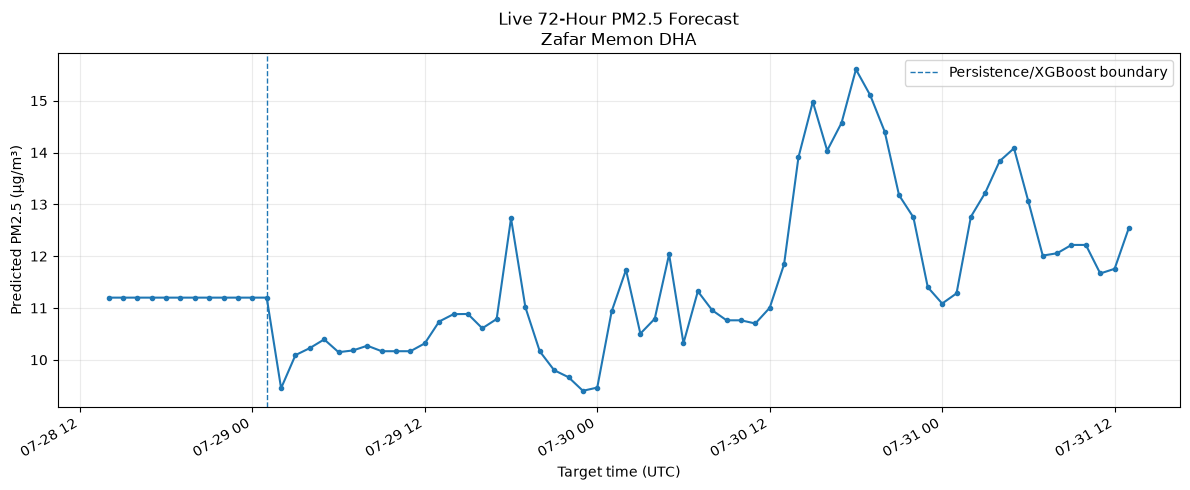

Saved forecast plot: /home/riyan/Riyan/projects/pearls-aqi-predictor/inference/runs/20260728T150416Z_d93945f7/forecast_plot.png


In [90]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(
    figsize=(12, 5)
)

axis.plot(
    live_pm25_forecast_df[
        "target_time"
    ],
    live_pm25_forecast_df[
        "predicted_pm25_ug_m3"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
)

routing_boundary_time = (
    selected_reference_time
    + pd.Timedelta(
        hours=(
            model_artifacts
            .persistence_max_horizon
        )
    )
)

axis.axvline(
    routing_boundary_time,
    linestyle="--",
    linewidth=1,
    label="Persistence/XGBoost boundary",
)

axis.set_title(
    "Live 72-Hour PM2.5 Forecast\n"
    f"{settings.location_name}"
)

axis.set_xlabel(
    "Target time (UTC)"
)

axis.set_ylabel(
    "Predicted PM2.5 (µg/m³)"
)

axis.grid(
    alpha=0.25
)

axis.legend()

figure.autofmt_xdate()
figure.tight_layout()

figure.savefig(
    saved_inference_run.forecast_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved forecast plot:",
    saved_inference_run.forecast_plot_path,
)

In [91]:
saved_run_paths = {
    "forecast parquet": (
        saved_inference_run
        .forecast_parquet_path
    ),
    "forecast csv": (
        saved_inference_run
        .forecast_csv_path
    ),
    "feature matrix": (
        saved_inference_run
        .feature_matrix_path
    ),
    "PM2.5 input": (
        saved_inference_run
        .pm25_input_path
    ),
    "weather input": (
        saved_inference_run
        .weather_input_path
    ),
    "run metadata": (
        saved_inference_run
        .metadata_path
    ),
    "validation report": (
        saved_inference_run
        .validation_report_path
    ),
    "forecast plot": (
        saved_inference_run
        .forecast_plot_path
    ),
}


saved_run_artifact_summary_df = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else None
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in saved_run_paths.items()
    ]
)

display(
    saved_run_artifact_summary_df
)

assert (
    saved_run_artifact_summary_df[
        "exists"
    ]
    .all()
)

assert (
    saved_run_artifact_summary_df[
        "size_bytes"
    ]
    .gt(0)
    .all()
)

,artifact,exists,size_bytes,path
0,forecast parquet,True,10532,/home/riyan/Riyan/projects/pearls-aqi-predicto...
1,forecast csv,True,17864,/home/riyan/Riyan/projects/pearls-aqi-predicto...
2,feature matrix,True,41724,/home/riyan/Riyan/projects/pearls-aqi-predicto...
3,PM2.5 input,True,6940,/home/riyan/Riyan/projects/pearls-aqi-predicto...
4,weather input,True,9959,/home/riyan/Riyan/projects/pearls-aqi-predicto...
5,run metadata,True,1562,/home/riyan/Riyan/projects/pearls-aqi-predicto...
6,validation report,True,1104,/home/riyan/Riyan/projects/pearls-aqi-predicto...
7,forecast plot,True,104853,/home/riyan/Riyan/projects/pearls-aqi-predicto...


In [92]:
reloaded_forecast_df = pd.read_parquet(
    saved_inference_run
    .forecast_parquet_path
)

reloaded_feature_matrix_df = (
    pd.read_parquet(
        saved_inference_run
        .feature_matrix_path
    )
)

reloaded_pm25_input_df = pd.read_parquet(
    saved_inference_run
    .pm25_input_path
)

reloaded_weather_input_df = pd.read_parquet(
    saved_inference_run
    .weather_input_path
)


pd.testing.assert_frame_equal(
    live_pm25_forecast_df.reset_index(
        drop=True
    ),
    reloaded_forecast_df.reset_index(
        drop=True
    ),
    check_dtype=True,
)

pd.testing.assert_frame_equal(
    live_feature_matrix_df.reset_index(
        drop=True
    ),
    reloaded_feature_matrix_df.reset_index(
        drop=True
    ),
    check_dtype=True,
)

pd.testing.assert_frame_equal(
    selected_pm25_history_df.reset_index(
        drop=True
    ),
    reloaded_pm25_input_df.reset_index(
        drop=True
    ),
    check_dtype=True,
)

pd.testing.assert_frame_equal(
    weather_input_for_run_df.reset_index(
        drop=True
    ),
    reloaded_weather_input_df.reset_index(
        drop=True
    ),
    check_dtype=True,
)

print(
    "Saved inference artifacts reloaded "
    "without data changes."
)

Saved inference artifacts reloaded without data changes.
